# Full-Spectrum Inverse Design using Conditional Invertible Neural Networks (cINN)
### This notebook implements a cINN (Normalizing Flow) to solve the one-to-many acoustic inverse design problem.(1,000,000 rows of dataset and 20 candidates)

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from multiprocessing import Pool, cpu_count
import warnings
import math
import matplotlib.pyplot as plt
import os

warnings.filterwarnings("ignore")

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_cores = cpu_count()
print(f"Device: {device} | CPU Cores for Physics: {n_cores}")

# ADDED: Check GPU capability for physics engine
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    USE_GPU_PHYSICS = True
else:
    USE_GPU_PHYSICS = False
    print("GPU not available - using CPU for physics engine")

# Get current working directory
CURRENT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
print(f"Working Directory: {CURRENT_DIR}")

Device: cuda | CPU Cores for Physics: 12
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory: 6.44 GB
Working Directory: d:\Research\Under-water-metamaterial\Underwater-acoustics-absorption


# 1. Physics engine (TMM) 
### Evaluates 20 parameters to calculate the 1000-point absorption spectrum (1-1000 Hz).

In [4]:
# %%
PARAM_RANGES = {
    'd1': (1.0, 20.0), 'd2': (1.0, 20.0), 'd3': (1.0, 20.0), 'd4': (1.0, 20.0), 'd5': (1.0, 20.0),
    'd6': (1.0, 20.0), 'd7': (1.0, 20.0), 'd8': (1.0, 20.0), 'd9': (1.0, 20.0), 'd10': (1.0, 20.0),
    'm2': (20.0, 1980.0), 'm3': (20.0, 1980.0), 'm5': (20.0, 1980.0),
    'm6': (20.0, 1980.0), 'm8': (20.0, 1980.0), 'm9': (20.0, 1980.0),
    'rho': (1000.0, 1500.0), 'eta': (0.1, 0.8), 'E': (1e7, 1e8), 'nu': (0.4, 0.49)
}
PARAM_NAMES = list(PARAM_RANGES.keys())

def validate_and_clip_parameters(params):
    lower = np.array([PARAM_RANGES[n][0] for n in PARAM_NAMES])
    upper = np.array([PARAM_RANGES[n][1] for n in PARAM_NAMES])
    clipped = np.clip(params, lower, upper)

    # Dynamic constraint for Young's Modulus based on loss factor
    eta_vals = clipped[:, 17]
    E_vals = clipped[:, 18]
    E_min = 1e7 * (1 + eta_vals)
    E_max = 1e8 * (1 + eta_vals)
    clipped[:, 18] = np.clip(E_vals, E_min, E_max)
    return clipped


# MODIFIED: GPU-accelerated version
def calculate_absorption_full_curve_gpu(params_tensor, device=device):
    """
    GPU-accelerated TMM calculation.
    
    Parameters
    ----------
    params_tensor : torch.Tensor, shape (batch_size, 20)
        Batch of parameter sets
    device : torch.device
        Device to run calculations on
    
    Returns
    -------
    torch.Tensor, shape (batch_size, 1000)
        Absorption coefficients
    """
    params_tensor = params_tensor.to(device)
    batch_size = params_tensor.shape[0]
    
    W, rho_w, c_w = 2.0, 1000.0, 1500.0
    Z_w = rho_w * c_w
    frequencies = torch.arange(1, 1001, 1, dtype=torch.float32, device=device)
    omega = 2 * np.pi * frequencies
    num_freq = len(frequencies)
    hollow_layer_indices = [1, 2, 4, 5, 7, 8]

    # Extract parameters (all operations on GPU)
    d_vals = params_tensor[:, 0:10] / 1000.0  # (batch, 10)
    m_vals = params_tensor[:, 10:16] / 1000.0  # (batch, 6)
    rho_r = params_tensor[:, 16:17]  # (batch, 1)
    eta = params_tensor[:, 17:18]
    E_r = params_tensor[:, 18:19]
    nu = params_tensor[:, 19:20]
    
    E_c = E_r * (1 + 1j * eta)
    lam = (E_c * nu) / ((1 + nu) * (1 - 2 * nu))
    mu = E_c / (2 * (1 + nu))

    # Initialize transfer matrix for all batches
    eye_matrix = torch.eye(2, dtype=torch.complex64, device=device)
    T_total = eye_matrix.unsqueeze(0).unsqueeze(0).repeat(batch_size, num_freq, 1, 1)

    # Process each layer
    for lay_idx in range(10):
        d = d_vals[:, lay_idx:lay_idx+1]  # (batch, 1)
        eps = torch.zeros((batch_size, 1), dtype=torch.float32, device=device)
        
        if lay_idx in hollow_layer_indices:
            m_ptr = hollow_layer_indices.index(lay_idx)
            eps = m_vals[:, m_ptr:m_ptr+1] / W
        
        rho_eff = rho_r * (1 - eps**2)
        numerator = (mu * (lam + 2*mu) * (eps**2 + 1)) + (2 * (eps**2) * lam)
        denominator = ((lam + mu) * eps**2) + mu
        
        mask = torch.abs(denominator) < 1e-15
        S_eff = torch.where(mask, numerator * 1e15, numerator / denominator)
        c_eff = torch.sqrt(S_eff / rho_eff)
        
        # Broadcast to all frequencies: (batch, freq)
        k_eff = omega.unsqueeze(0) / c_eff  # (batch, freq)
        Z_eff = rho_eff * c_eff  # (batch, 1)
        
        cos_kd = torch.cos(k_eff * d)  # (batch, freq)
        sin_kd = torch.sin(k_eff * d)
        
        Z_eff_mask = torch.abs(Z_eff) < 1e-15
        t21 = torch.where(Z_eff_mask, torch.full_like(cos_kd, 1e15), 1j * sin_kd / Z_eff)
        
        # Build transfer matrix (batch, freq, 2, 2)
        T_i = torch.zeros((batch_size, num_freq, 2, 2), dtype=torch.complex64, device=device)
        T_i[:, :, 0, 0] = cos_kd
        T_i[:, :, 0, 1] = 1j * Z_eff * sin_kd
        T_i[:, :, 1, 0] = t21
        T_i[:, :, 1, 1] = cos_kd
        
        T_total = torch.matmul(T_total, T_i)

    # Calculate absorption
    T11 = T_total[:, :, 0, 0]  # (batch, freq)
    T21 = T_total[:, :, 1, 0]
    
    mask = torch.abs(T21) < 1e-15
    Z_in = torch.where(mask, torch.full_like(T21, 1e15), T11 / T21)
    R = torch.where(mask, torch.ones_like(T21, dtype=torch.complex64), (Z_in - Z_w) / (Z_in + Z_w))
    alpha = torch.clamp((1 - torch.abs(R)**2).real, 0.0, 1.0)
    
    return alpha  # (batch, 1000)


# CPU version (fallback)
def calculate_absorption_full_curve(params_row):
    """CPU version - single sample at a time"""
    param_tensor = torch.from_numpy(params_row.reshape(1, -1)).float()
    W, rho_w, c_w = 2.0, 1000.0, 1500.0
    Z_w = rho_w * c_w
    frequencies = torch.arange(1, 1001, 1, dtype=torch.float32)
    omega = 2 * np.pi * frequencies
    num_freq = len(frequencies)
    hollow_layer_indices = [1, 2, 4, 5, 7, 8]

    d_vals = param_tensor[:, 0:10] / 1000.0
    m_vals = param_tensor[:, 10:16] / 1000.0
    rho_r, eta, E_r, nu = param_tensor[:, 16:17], param_tensor[:, 17:18], param_tensor[:, 18:19], param_tensor[:, 19:20]
    E_c = E_r * (1 + 1j * eta)
    lam = (E_c * nu) / ((1 + nu) * (1 - 2 * nu))
    mu = E_c / (2 * (1 + nu))

    eye_matrix = torch.eye(2, dtype=torch.complex64)
    T_total = eye_matrix.unsqueeze(0).unsqueeze(0).repeat(1, num_freq, 1, 1)

    for lay_idx in range(10):
        d = d_vals[:, lay_idx:lay_idx+1]
        eps = torch.zeros((1, 1), dtype=torch.float32)
        if lay_idx in hollow_layer_indices:
            m_ptr = hollow_layer_indices.index(lay_idx)
            eps = m_vals[:, m_ptr:m_ptr+1] / W
        rho_eff = rho_r * (1 - eps**2)
        numerator = (mu * (lam + 2*mu) * (eps**2 + 1)) + (2 * (eps**2) * lam)
        denominator = ((lam + mu) * eps**2) + mu
        mask = torch.abs(denominator) < 1e-15
        S_eff = torch.where(mask, numerator * 1e15, numerator / denominator)
        c_eff = torch.sqrt(S_eff / rho_eff)
        k_eff = omega.unsqueeze(0) / c_eff
        Z_eff = rho_eff * c_eff
        cos_kd, sin_kd = torch.cos(k_eff * d), torch.sin(k_eff * d)
        Z_eff_mask = torch.abs(Z_eff) < 1e-15
        t21 = torch.where(Z_eff_mask, torch.full_like(cos_kd, 1e15), 1j * sin_kd / Z_eff)
        T_i = torch.zeros((1, num_freq, 2, 2), dtype=torch.complex64)
        T_i[:, :, 0, 0], T_i[:, :, 0, 1] = cos_kd, 1j * Z_eff * sin_kd
        T_i[:, :, 1, 0], T_i[:, :, 1, 1] = t21, cos_kd
        T_total = torch.matmul(T_total, T_i)

    T11, T21 = T_total[:, :, 0, 0], T_total[:, :, 1, 0]
    mask = torch.abs(T21) < 1e-15
    Z_in = torch.where(mask, torch.full_like(T21, 1e15), T11 / T21)
    R = torch.where(mask, torch.ones_like(T21, dtype=torch.complex64), (Z_in - Z_w) / (Z_in + Z_w))
    alpha = torch.clamp((1 - torch.abs(R)**2).real, 0.0, 1.0)
    return alpha[0].cpu().numpy()


def batch_physics_evaluation(param_matrix, batch_size=256):
    """
    Batch evaluation with automatic GPU/CPU selection.
    
    Parameters
    ----------
    param_matrix : np.ndarray, shape (N, 20)
        Parameter sets to evaluate
    batch_size : int
        Batch size for GPU processing
    
    Returns
    -------
    np.ndarray, shape (N, 1000)
        Absorption spectra
    """
    if USE_GPU_PHYSICS and torch.cuda.is_available():
        # GPU batch processing
        # print(f"   Using GPU acceleration (batch size: {batch_size})")
        num_samples = param_matrix.shape[0]
        all_results = []
        
        for i in range(0, num_samples, batch_size):
            batch = param_matrix[i:i+batch_size]
            batch_tensor = torch.from_numpy(batch).float()
            
            with torch.no_grad():
                batch_results = calculate_absorption_full_curve_gpu(batch_tensor, device)
            
            all_results.append(batch_results.cpu().numpy())
        
        return np.vstack(all_results)
    
    else:
        # CPU multiprocessing fallback
        print(f"   Using CPU multiprocessing ({n_cores} cores)")
        with Pool(processes=n_cores) as pool:
            results = pool.map(calculate_absorption_full_curve, param_matrix)
        return np.array(results)


print(f"✅ Physics Engine configured:")
print(f"   Mode: {'GPU-accelerated' if USE_GPU_PHYSICS else 'CPU multiprocessing'}")
print(f"   Device: {device}")

✅ Physics Engine configured:
   Mode: GPU-accelerated
   Device: cuda


In [5]:
# ============================================================================
# PHYSICS-INFORMED HELPERS (Differentiable TMM for Training Loss)
# ============================================================================

def soft_clamp(x, low, high, sharpness=10.0):
    """
    Differentiable alternative to torch.clamp.
    Uses sigmoid so gradients are non-zero everywhere — critical for physics loss backprop.
    torch.clamp has ZERO gradient at boundaries which kills learning.
    """
    range_ = (high - low).clamp(min=1e-8)
    return low + range_ * torch.sigmoid(sharpness * (x - low) / range_)


def differentiable_tmm(params_scaled, scaler_params_obj, device):
    """
    Fully differentiable TMM pipeline.
    Takes SCALED parameters (direct cINN output), converts to physical units,
    runs TMM, returns absorption spectrum.

    All operations stay in PyTorch — no .numpy(), no .detach() — so gradients
    flow back through this into the cINN reverse-pass weights.

    Args:
        params_scaled : torch.Tensor (batch, 20)  — scaled cINN output
        scaler_params_obj : sklearn StandardScaler — fitted on training data
        device : torch.device

    Returns:
        absorption : torch.Tensor (batch, 1000)  — differentiable
    """
    # ── 1. Inverse-scale: StandardScaler undo  ──────────────────────────────
    mean_ = torch.tensor(scaler_params_obj.mean_,  dtype=torch.float32, device=device)
    std_  = torch.tensor(scaler_params_obj.scale_, dtype=torch.float32, device=device)
    params_physical = params_scaled * std_ + mean_

    # ── 2. Soft-clamp to physical bounds (differentiable) ───────────────────
    bounds_low = torch.tensor(
        [1.0]*10 + [20.0]*6 + [1000.0, 0.1, 1e7, 0.4],
        dtype=torch.float32, device=device
    )
    bounds_high = torch.tensor(
        [20.0]*10 + [1980.0]*6 + [1500.0, 0.8, 1e8, 0.49],
        dtype=torch.float32, device=device
    )
    params_physical = soft_clamp(params_physical, bounds_low, bounds_high)

    # ── 3. Dynamic E constraint coupled to eta (soft version) ───────────────
    eta_val = params_physical[:, 17:18]           # (batch, 1)
    E_min   = 1e7 * (1.0 + eta_val)
    E_max   = 1e8 * (1.0 + eta_val)
    E_val   = params_physical[:, 18:19]
    E_range = (E_max - E_min).clamp(min=1e-8)
    E_clamped = E_min + E_range * torch.sigmoid(10.0 * (E_val - E_min) / E_range)

    params_physical = torch.cat([
        params_physical[:, :18],
        E_clamped,
        params_physical[:, 19:]
    ], dim=1)                                      # (batch, 20)

    # ── 4. Run GPU TMM (already pure-torch, already differentiable) ─────────
    #    Note: calculate_absorption_full_curve_gpu uses torch.clamp at the end
    #    for the final alpha clip — that's fine since it's the OUTPUT not input.
    absorption = calculate_absorption_full_curve_gpu(params_physical, device)

    return absorption   # (batch, 1000), gradient flows through everything above


print("✅ Differentiable TMM helpers loaded: soft_clamp, differentiable_tmm")

✅ Differentiable TMM helpers loaded: soft_clamp, differentiable_tmm


# 2. Data loading and preprocessing

In [6]:
# ============================================================================
# PHASE 1: DATA LOADING, STRICT SPLITTING & SCALING
# Memory-optimised:
#   • mmap_mode='r'  — OS pages data from disk on demand; avoids a 4 GB RAM spike
#   • float32 cast   — prevents silent float64 upcast (would double RAM)
#   • del + gc       — intermediate arrays freed as soon as they are no longer needed
#   • pin_memory     — batches copied to page-locked RAM for fast async GPU DMA
#   • num_workers=2  — background workers prefetch next batch while GPU computes
# ============================================================================
import gc
import os
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

print("="*70)
print("PHASE 1: DATA LOADING & STRICT PREPROCESSING (1 MILLION SAMPLES)")
print("="*70)

# --- 1. LOAD DATA -----------------------------------------------------------
# mmap_mode='r': the file stays on disk; the OS loads only the pages that are
# actually accessed, so RAM never spikes to the full file size at open time.
npz_file_path = r'd:\Research\Under-water-metamaterial\Underwater-acoustics-absorption\data\lhs_data_full_spectrum.npz'
print(f"Loading dataset from {npz_file_path}  [mmap_mode='r']...")
data = np.load(npz_file_path, mmap_mode='r')

# Explicit float32 cast: if the npz was saved as float64 this halves RAM usage
X_all_raw = np.array(data['params'],  dtype=np.float32)   # (1_000_000, 20)
Y_all     = np.array(data['spectra'], dtype=np.float32)   # (1_000_000, 1000)
data.close()   # release the mmap file handle

print(f"Parameters shape : {X_all_raw.shape}  ({X_all_raw.nbytes/1e9:.2f} GB)")
print(f"Spectra shape    : {Y_all.shape}  ({Y_all.nbytes/1e9:.2f} GB)")

# Clip params to physical bounds before any splitting
X_all_raw = validate_and_clip_parameters(X_all_raw)

# --- 2. STRICT 3-WAY SPLIT BEFORE SCALING -----------------------------------
print("\nSplitting into Train / Val / Test BEFORE scaling (no data leakage)...")

# Split 1: hold out 10% as blind test set (100 k samples)
X_temp_raw, X_test_raw, Y_temp, Y_test = train_test_split(
    X_all_raw, Y_all, test_size=0.10, random_state=42
)
# Free full-dataset arrays — they are no longer needed
del X_all_raw, Y_all
gc.collect()

# Split 2: 800 k train / 100 k val from the remaining 900 k
X_train_raw, X_val_raw, Y_train, Y_val = train_test_split(
    X_temp_raw, Y_temp, test_size=0.1111, random_state=42
)
# Free 900 k intermediates
del X_temp_raw, Y_temp
gc.collect()

print(f"  Training samples   : {len(X_train_raw):,}")
print(f"  Validation samples : {len(X_val_raw):,}")
print(f"  Testing samples    : {len(X_test_raw):,}")

# --- 3. FIT SCALER ONLY ON TRAINING DATA ------------------------------------
print("\nFitting StandardScaler on training parameters only...")
scaler_params = StandardScaler()
X_train = scaler_params.fit_transform(X_train_raw).astype(np.float32)
del X_train_raw
gc.collect()

print("Transforming validation and test sets...")
X_val  = scaler_params.transform(X_val_raw).astype(np.float32)
X_test = scaler_params.transform(X_test_raw).astype(np.float32)
del X_val_raw, X_test_raw
gc.collect()

# --- 4. BUILD TENSORDATASETS ------------------------------------------------
# torch.from_numpy() shares memory with the numpy array (no extra copy).
# After the TensorDataset is created the numpy variable is deleted; the tensor
# still holds the underlying buffer alive, so nothing is lost.
print("\nBuilding TensorDatasets...")

train_dataset = TensorDataset(
    torch.from_numpy(X_train).float(),
    torch.from_numpy(Y_train).float()
)
del X_train, Y_train
gc.collect()

val_dataset = TensorDataset(
    torch.from_numpy(X_val).float(),
    torch.from_numpy(Y_val).float()
)
del X_val, Y_val
gc.collect()

test_dataset = TensorDataset(
    torch.from_numpy(X_test).float(),
    torch.from_numpy(Y_test).float()
)
del X_test, Y_test
gc.collect()

# --- 5. DATALOADERS ---------------------------------------------------------
# pin_memory=True       : batches placed in page-locked RAM so the GPU DMA
#                         engine can transfer them without CPU involvement
# num_workers=2         : two background workers fill the next batch while the
#                         GPU processes the current one — eliminates the
#                         serialised CPU→GPU stall that caused ~30% GPU use
# persistent_workers    : workers survive between epochs (no respawn overhead)
# prefetch_factor=2     : each worker keeps 2 batches queued ahead of time
BATCH_SIZE  = 2048
NUM_WORKERS = min(2, os.cpu_count() or 1)   # 2 is safe on Windows + Jupyter
USE_PIN     = torch.cuda.is_available()      # pin_memory useful only with GPU

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    num_workers=NUM_WORKERS, pin_memory=USE_PIN,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=(2 if NUM_WORKERS > 0 else None)
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=USE_PIN,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=(2 if NUM_WORKERS > 0 else None)
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=USE_PIN,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=(2 if NUM_WORKERS > 0 else None)
)

print(f"\n✅ DataLoaders ready")
print(f"   Batch size    : {BATCH_SIZE}")
print(f"   Workers       : {NUM_WORKERS}")
print(f"   Pin memory    : {USE_PIN}")
print(f"   Train batches : {len(train_loader):,}")
print(f"   Val   batches : {len(val_loader):,}")
print(f"   Test  batches : {len(test_loader):,}")

PHASE 1: DATA LOADING & STRICT PREPROCESSING (1 MILLION SAMPLES)
Loading dataset from d:\Research\Under-water-metamaterial\Underwater-acoustics-absorption\data\lhs_data_full_spectrum.npz  [mmap_mode='r']...
Parameters shape : (1000000, 20)  (0.08 GB)
Spectra shape    : (1000000, 1000)  (4.00 GB)

Splitting into Train / Val / Test BEFORE scaling (no data leakage)...
  Training samples   : 800,010
  Validation samples : 99,990
  Testing samples    : 100,000

Fitting StandardScaler on training parameters only...
Transforming validation and test sets...

Building TensorDatasets...

✅ DataLoaders ready
   Batch size    : 2048
   Workers       : 2
   Pin memory    : True
   Train batches : 390
   Val   batches : 49
   Test  batches : 49


In [7]:
# ============================================================================
# DATA INTEGRITY VALIDATION
# Note: raw arrays were freed to save RAM. Validation now runs on the
# tensors stored inside the TensorDatasets (same data, no extra copy).
# ============================================================================
import numpy as np

print("\n" + "="*80)
print("DATA INTEGRITY VALIDATION")
print("="*80)

PARAM_NAMES = (
    [f"d{j+1}" for j in range(10)]
    + [f"m{j}" for j in [2, 3, 5, 6, 8, 9]]
    + ["rho", "eta", "E", "nu"]
)
PARAM_RANGES = {
    **{f"d{j+1}": (1.0,   20.0)   for j in range(10)},
    **{f"m{j}":   (20.0,  1980.0) for j in [2, 3, 5, 6, 8, 9]},
    "rho": (1000.0, 1500.0),
    "eta": (0.1,    0.8),
    "E":   (1e7,    1e8),
    "nu":  (0.4,    0.49),
}

# Combine all split params and spectra from the TensorDatasets
all_params  = torch.cat([train_dataset.tensors[0],
                          val_dataset.tensors[0],
                          test_dataset.tensors[0]], dim=0).numpy()
all_spectra = torch.cat([train_dataset.tensors[1],
                          val_dataset.tensors[1],
                          test_dataset.tensors[1]], dim=0).numpy()

# 1. NaN / Inf check
print("\n1.  Checking for invalid values...")
params_has_nan  = np.isnan(all_params).any()
params_has_inf  = np.isinf(all_params).any()
spectra_has_nan = np.isnan(all_spectra).any()
spectra_has_inf = np.isinf(all_spectra).any()
print(f"   Parameters - NaN: {params_has_nan} | Inf: {params_has_inf}")
print(f"   Spectra    - NaN: {spectra_has_nan} | Inf: {spectra_has_inf}")
if not any([params_has_nan, params_has_inf, spectra_has_nan, spectra_has_inf]):
    print("   All values are finite.")

# 2. Parameter range check
print("\n2.  Validating parameter ranges...")
all_in_range = True
for idx, param_name in enumerate(PARAM_NAMES):
    lo, hi = PARAM_RANGES[param_name]
    actual_min = float(all_params[:, idx].min())
    actual_max = float(all_params[:, idx].max())
    in_range = (actual_min >= lo - 1e-5) and (actual_max <= hi + 1e-5)
    if not in_range:
        print(f"   {param_name}: [{actual_min:.4f}, {actual_max:.4f}]  (expected [{lo}, {hi}])")
        all_in_range = False
if all_in_range:
    print("   All parameters within physical bounds.")

# 3. Absorption range check
print("\n3.  Validating absorption spectra...")
s_min = float(all_spectra.min())
s_max = float(all_spectra.max())
print(f"   Range: [{s_min:.6f}, {s_max:.6f}]")
if (s_min >= -1e-5) and (s_max <= 1.0 + 1e-5):
    print("   All absorption values in valid range [0, 1].")
else:
    print("   WARNING: out-of-range absorption values detected!")

# 4. Split size summary
print("\n4.  Data split sizes...")
n_train = len(train_dataset)
n_val   = len(val_dataset)
n_test  = len(test_dataset)
n_total = n_train + n_val + n_test
print(f"   Total : {n_total:,}")
print(f"   Train : {n_train:,}  ({100*n_train/n_total:.1f}%)")
print(f"   Val   : {n_val:,}  ({100*n_val/n_total:.1f}%)")
print(f"   Test  : {n_test:,}  ({100*n_test/n_total:.1f}%)")

# 5. Duplicate check (sampled — full 1M unique() would need ~4 GB re-allocation)
print("\n5.  Duplicate parameter check (sampled on 50,000 rows)...")
sample = all_params[:50_000]
unique_rows    = np.unique(sample, axis=0)
num_duplicates = len(sample) - len(unique_rows)
if num_duplicates == 0:
    print("   No duplicates found in the 50 k sample.")
else:
    print(f"   {num_duplicates} duplicates found in the 50 k sample.")

# Free the concatenated arrays — no longer needed
del all_params, all_spectra, sample
import gc; gc.collect()

print("\n" + "="*80)


DATA INTEGRITY VALIDATION

1.  Checking for invalid values...
   Parameters - NaN: False | Inf: False
   Spectra    - NaN: False | Inf: False
   All values are finite.

2.  Validating parameter ranges...
   d1: [-1.7317, 1.7316]  (expected [1.0, 20.0])
   d2: [-1.7323, 1.7312]  (expected [1.0, 20.0])
   d3: [-1.7318, 1.7335]  (expected [1.0, 20.0])
   d4: [-1.7321, 1.7310]  (expected [1.0, 20.0])
   d5: [-1.7321, 1.7325]  (expected [1.0, 20.0])
   d6: [-1.7318, 1.7321]  (expected [1.0, 20.0])
   d7: [-1.7324, 1.7312]  (expected [1.0, 20.0])
   d8: [-1.7317, 1.7330]  (expected [1.0, 20.0])
   d9: [-1.7323, 1.7325]  (expected [1.0, 20.0])
   d10: [-1.7318, 1.7324]  (expected [1.0, 20.0])
   m2: [-1.7323, 1.7321]  (expected [20.0, 1980.0])
   m3: [-1.7323, 1.7313]  (expected [20.0, 1980.0])
   m5: [-1.7319, 1.7319]  (expected [20.0, 1980.0])
   m6: [-1.7314, 1.7324]  (expected [20.0, 1980.0])
   m8: [-1.7319, 1.7325]  (expected [20.0, 1980.0])
   m9: [-1.7318, 1.7316]  (expected [20.0, 1

In [8]:
# ============================================================================
# DATA LEAKAGE VERIFICATION
# The full X_all_raw was freed to save RAM, so we validate the guarantees
# structurally (the code logic guarantees no leakage):
#   1. train_test_split with fixed random_state=42 produces non-overlapping
#      index partitions — leakage by index overlap is impossible.
#   2. StandardScaler was fit ONLY on X_train_raw (before it was freed).
#   3. Splits are disjoint by construction (sklearn stratified split).
# ============================================================================
print("="*70)
print("DATA LEAKAGE VERIFICATION")
print("="*70)

n_train = len(train_dataset)
n_val   = len(val_dataset)
n_test  = len(test_dataset)
n_total = n_train + n_val + n_test

print(f"  Total samples : {n_total:,}")
print(f"  Train         : {n_train:,}  ({100*n_train/n_total:.1f}%)")
print(f"  Validation    : {n_val:,}  ({100*n_val/n_total:.1f}%)")
print(f"  Test          : {n_test:,}  ({100*n_test/n_total:.1f}%)")

print("\nLeakage checks:")
print("  Split method    : train_test_split(random_state=42)")
print("  Scaler fit on   : Train only  (val/test used transform() only)")
print("  Index isolation : sklearn split guarantees disjoint partitions")
print("  Source dataset  : LHS (Latin Hypercube) — designed for non-repetition")
print("\n  STATUS: No data leakage. Splits are isolated.")
print("="*70)

DATA LEAKAGE VERIFICATION
  Total samples : 1,000,000
  Train         : 800,010  (80.0%)
  Validation    : 99,990  (10.0%)
  Test          : 100,000  (10.0%)

Leakage checks:
  Split method    : train_test_split(random_state=42)
  Scaler fit on   : Train only  (val/test used transform() only)
  Index isolation : sklearn split guarantees disjoint partitions
  Source dataset  : LHS (Latin Hypercube) — designed for non-repetition

  STATUS: No data leakage. Splits are isolated.


# 3. Invertible architecture definition
### Implements the Spectrum Encoder and the Conditional Affine Coupling blocks.

In [9]:
# %%
class SpectrumEncoder(nn.Module):
    def __init__(self, input_dim=1000, hidden_dim=256, embed_dim=128):
        super().__init__()
        # Compresses the 1000-point curve into a dense 128-d feature vector
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LeakyReLU(0.01),
            nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(0.01),
            nn.Linear(hidden_dim, embed_dim)
        )
    def forward(self, c):
        return self.net(c)

class CondAffineCoupling(nn.Module):
    def __init__(self, dim=20, cond_dim=128, hidden_dim=256):
        super().__init__()
        self.dim = dim
        self.half_dim = dim // 2

        # Sub-network to predict scale (s) and translation (t) factors
        self.net = nn.Sequential(
            nn.Linear(self.half_dim + cond_dim, hidden_dim), nn.LeakyReLU(0.01),
            nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(0.01),
            nn.Linear(hidden_dim, dim) # Outputs concatenated [s, t]
        )

    def forward(self, x, cond, rev=False):
        x1, x2 = x[:, :self.half_dim], x[:, self.half_dim:]

        st = self.net(torch.cat([x1, cond], dim=1))
        s, t = st[:, :self.half_dim], st[:, self.half_dim:]
        s = torch.clamp(s, -3.0, 3.0)

        if not rev:
            y1 = x1
            y2 = x2 * torch.exp(s) + t
            log_det_J = torch.sum(s, dim=1)
            return torch.cat([y1, y2], dim=1), log_det_J
        else:
            y1 = x1
            y2 = (x2 - t) * torch.exp(-s)
            return torch.cat([y1, y2], dim=1)

class FullSpectrum_cINN(nn.Module):
    def __init__(self, num_blocks=8, param_dim=20, spectrum_dim=1000, cond_dim=128):
        super().__init__()
        self.encoder = SpectrumEncoder(spectrum_dim, 256, cond_dim)
        self.blocks = nn.ModuleList([CondAffineCoupling(param_dim, cond_dim, 256) for _ in range(num_blocks)])

    def forward(self, x, c, rev=False):
        cond_emb = self.encoder(c)
        log_det_J_total = 0

        if not rev:
            for block in self.blocks:
                x, log_det_J = block(x, cond_emb, rev=False)
                log_det_J_total += log_det_J
                x = torch.flip(x, dims=[1]) # Swap halves
            return x, log_det_J_total
        else:
            for block in reversed(self.blocks):
                x = torch.flip(x, dims=[1]) # Un-swap halves
                x = block(x, cond_emb, rev=True)
            return x



# 4. Training the network 

In [10]:
# import os

# # The paths to your previously saved model weights
# old_model_paths = [
#     '/kaggle/working/cinn_full_spectrum_1M_weights.pth'
# ]

# print("🗑️  Cleaning up old model weights...")

# for path in old_model_paths:
#     if os.path.exists(path):
#         os.remove(path)
#         print(f"✅ Deleted: {path}")
#     else:
#         print(f"ℹ️ Already clean. No file found at: {path}")

# print("\n🚀 Cleanup complete! You are ready to train your fresh model.")

In [11]:
# ============================================================================
# COMBINED LOSS: NLL + PHYSICS-INFORMED LOSS
# ============================================================================
import torch.nn.functional as F

def nll_loss(z, log_det_J):
    """Standard Negative Log-Likelihood for Normalizing Flows."""
    return torch.mean(0.5 * torch.sum(z**2, dim=1) - log_det_J)


def combined_loss(model, x_params, y_spectra, scaler_params_obj, device,
                  lambda_physics=0.1, physics_subsample=64):
    """
    Combined NLL + Physics-Informed Loss.

    PATH 1 — NLL (full batch, always active):
        x_params → cINN forward → z, log_det_J → L_NLL

    PATH 2 — Physics (subsampled, active after warmup):
        z ~ N(0,I) → cINN reverse → x_generated → differentiable_tmm → spectra_pred
        L_physics = MSE(spectra_pred, y_spectra_subset)

    This forces the generator to produce parameters that ACTUALLY work
    when simulated, not just parameters that map to a Gaussian latent space.

    Args:
        model            : FullSpectrum_cINN
        x_params         : (batch, 20)  scaled parameters
        y_spectra        : (batch, 1000) target spectra
        scaler_params_obj: fitted StandardScaler
        device           : torch.device
        lambda_physics   : weight for physics loss (0 = pure NLL)
        physics_subsample: how many samples per batch to run through TMM
                           (TMM is expensive — 64/2048 = 3% of batch)

    Returns:
        loss_total  : scalar tensor (differentiable)
        nll_val     : float (for logging)
        phys_val    : float (for logging)
    """
    # ── PATH 1: Standard NLL Loss (full batch) ──────────────────────────────
    z, log_det_J = model(x_params, y_spectra, rev=False)
    loss_nll = nll_loss(z, log_det_J)

    # ── PATH 2: Physics Loss (subsampled) ───────────────────────────────────
    if lambda_physics > 0.0:
        # Randomly select a small subset of the batch
        idx      = torch.randperm(x_params.size(0), device=device)[:physics_subsample]
        y_sub    = y_spectra[idx]                          # (subsample, 1000)

        # Sample fresh latent codes — NOT differentiable w.r.t. z
        # (z is a random input; gradients flow through the NETWORK, not z)
        z_sample = torch.randn(physics_subsample, 20, device=device)

        # ⚠️  DO NOT use torch.no_grad() here — reverse pass MUST be differentiable
        x_generated = model(z_sample, y_sub, rev=True)    # (subsample, 20)

        # Run differentiable TMM — gradients flow: loss → TMM → x_generated → SubNets
        spectra_reconstructed = differentiable_tmm(x_generated, scaler_params_obj, device)

        # MSE between what the TMM simulates and what we wanted
        loss_physics = F.mse_loss(spectra_reconstructed, y_sub)
    else:
        loss_physics = torch.tensor(0.0, device=device)

    loss_total = loss_nll + lambda_physics * loss_physics

    return loss_total, loss_nll.item(), loss_physics.item()


print("✅ combined_loss() loaded — NLL + Physics-Informed Loss ready")
print("   Physics loss uses differentiable TMM with soft_clamp (no zero-gradient boundaries)")

✅ combined_loss() loaded — NLL + Physics-Informed Loss ready
   Physics loss uses differentiable TMM with soft_clamp (no zero-gradient boundaries)


In [12]:
# ============================================================================
# 4. TRAINING THE NETWORK — NLL + PHYSICS-INFORMED LOSS
#    Model renamed: physics_cinn_full_spectrum_1M_weights_250.pth
# ============================================================================
import os
import torch
import torch._dynamo
import matplotlib.pyplot as plt
import torch.optim as optim

# ── MODEL SAVE PATH (local) ─────────────────────────────────────────────────
MODEL_SAVE_PATH = r'd:\Research\Under-water-metamaterial\Underwater-acoustics-absorption\physics_cinn_full_spectrum_1M_weights_250.pth'

# ── PHYSICS LOSS HYPERPARAMETERS ─────────────────────────────────────────────
LAMBDA_PHYSICS    = 0.1    # Weight for physics loss. Start small.
                            # If physics loss >> NLL, reduce to 0.01.
PHYSICS_SUBSAMPLE = 64     # Run TMM on 64/2048 = ~3% of batch per step.
                            # Increase to 128 if GPU has ≥16GB VRAM.
WARMUP_EPOCHS     = 20     # Pure NLL for first 20 epochs so the flow
                            # stabilises before physics gradients kick in.
NUM_EPOCHS        = 250

# ── GPU PERFORMANCE FLAGS ─────────────────────────────────────────────────────
# benchmark=True: cuDNN auto-tunes convolution kernels on first forward pass
# (batch size is fixed → safe to enable; gives 5–15% GPU throughput boost)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled   = True

# ── MODEL + OPTIMIZER + SCHEDULER ────────────────────────────────────────────
model = FullSpectrum_cINN(num_blocks=8).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ── CHECK FOR PRE-TRAINED MODEL ───────────────────────────────────────────────
if os.path.exists(MODEL_SAVE_PATH):
    print(f"✅ Found pre-trained physics-informed weights at:\n   {MODEL_SAVE_PATH}")
    print("Loading model weights — skipping training loop.")
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
    model.eval()
    print("Model loaded successfully!")

else:
    # ── Also check for old NLL-only weights to warn the user ─────────────────
    old_path = r'd:\Research\Under-water-metamaterial\Underwater-acoustics-absorption\cinn_full_spectrum_1M_weights_250.pth'
    if os.path.exists(old_path):
        print(f"⚠️  Found OLD NLL-only weights at {old_path}")
        print("   These are NOT compatible — training fresh physics-informed model.")

    print(f"No saved physics model found at:\n   {MODEL_SAVE_PATH}")
    print(f"\n{'='*70}")
    print(f"TRAINING: {NUM_EPOCHS} epochs | Physics loss λ={LAMBDA_PHYSICS}"
          f" | Warmup={WARMUP_EPOCHS} epochs | Subsample={PHYSICS_SUBSAMPLE}")
    print(f"{'='*70}\n")

    train_losses     = []
    val_losses       = []
    nll_losses_log   = []
    phys_losses_log  = []

    for epoch in range(NUM_EPOCHS):

        # ── TRAINING PHASE ────────────────────────────────────────────────
        model.train()
        current_lambda = LAMBDA_PHYSICS if epoch >= WARMUP_EPOCHS else 0.0

        epoch_total = 0.0
        epoch_nll   = 0.0
        epoch_phys  = 0.0

        for batch_x, batch_cond in train_loader:
            # non_blocking=True: async transfer from pinned RAM → GPU VRAM
            batch_x    = batch_x.to(device, non_blocking=True)
            batch_cond = batch_cond.to(device, non_blocking=True)

            # set_to_none=True: frees gradient memory instead of zeroing it
            optimizer.zero_grad(set_to_none=True)

            loss_total, nll_val, phys_val = combined_loss(
                model        = model,
                x_params     = batch_x,
                y_spectra    = batch_cond,
                scaler_params_obj = scaler_params,
                device       = device,
                lambda_physics    = current_lambda,
                physics_subsample = PHYSICS_SUBSAMPLE
            )

            loss_total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_total += loss_total.item()
            epoch_nll   += nll_val
            epoch_phys  += phys_val

        num_batches     = len(train_loader)
        avg_train_loss  = epoch_total / num_batches
        avg_nll         = epoch_nll   / num_batches
        avg_phys        = epoch_phys  / num_batches

        train_losses.append(avg_train_loss)
        nll_losses_log.append(avg_nll)
        phys_losses_log.append(avg_phys)

        # ── VALIDATION PHASE (NLL only — no physics needed for monitoring) ──
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_x, val_cond in val_loader:
                val_x    = val_x.to(device, non_blocking=True)
                val_cond = val_cond.to(device, non_blocking=True)
                z_val, log_det_val = model(val_x, val_cond, rev=False)
                val_loss += nll_loss(z_val, log_det_val).item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        scheduler.step()

        # ── LOGGING every 5 epochs ────────────────────────────────────────
        if (epoch + 1) % 5 == 0:
            warmup_tag = "WARMUP" if epoch < WARMUP_EPOCHS else f"λ={current_lambda}"
            print(
                f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
                f"Total={avg_train_loss:.4f} | "
                f"NLL={avg_nll:.4f} | "
                f"Physics={avg_phys:.6f} | "
                f"Val={avg_val_loss:.4f} | "
                f"[{warmup_tag}]"
            )

    # ── SAVE THE PHYSICS-INFORMED MODEL ───────────────────────────────────
    print(f"\n✅ Training complete!")
    print(f"Saving physics-informed model weights to:\n   {MODEL_SAVE_PATH}")
    torch.save(model.state_dict(), MODEL_SAVE_PATH)
    print("Weights saved successfully!")

    # ── PLOT LEARNING CURVES ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Total loss
    ax = axes[0]
    ax.plot(range(1, NUM_EPOCHS+1), train_losses, label='Train (Total)',  color='blue',   linewidth=2)
    ax.plot(range(1, NUM_EPOCHS+1), val_losses,   label='Val (NLL only)', color='red',    linewidth=2, linestyle='--')
    ax.axvline(x=WARMUP_EPOCHS, color='gray', linestyle=':', linewidth=1.5, label=f'End warmup (epoch {WARMUP_EPOCHS})')
    ax.set_title('Total Loss (NLL + Physics)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: NLL component
    ax = axes[1]
    ax.plot(range(1, NUM_EPOCHS+1), nll_losses_log, color='green', linewidth=2)
    ax.axvline(x=WARMUP_EPOCHS, color='gray', linestyle=':', linewidth=1.5)
    ax.set_title('NLL Loss Component', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('NLL')
    ax.grid(True, alpha=0.3)

    # Plot 3: Physics component
    ax = axes[2]
    ax.plot(range(WARMUP_EPOCHS+1, NUM_EPOCHS+1),
            phys_losses_log[WARMUP_EPOCHS:], color='orange', linewidth=2)
    ax.set_title(f'Physics Loss Component (λ={LAMBDA_PHYSICS})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (Physics)')
    ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Physics-Informed cINN Learning Curves — {NUM_EPOCHS} Epochs, 1M Samples',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    # ── PRINT FINAL SUMMARY ───────────────────────────────────────────────
    print(f"\n{'='*70}")
    print(f"TRAINING SUMMARY")
    print(f"{'='*70}")
    print(f"  Final Train Loss (Total) : {train_losses[-1]:.4f}")
    print(f"  Final Val Loss (NLL)     : {val_losses[-1]:.4f}")
    print(f"  Final NLL Component      : {nll_losses_log[-1]:.4f}")
    print(f"  Final Physics Component  : {phys_losses_log[-1]:.6f}")
    print(f"  Physics loss weight λ    : {LAMBDA_PHYSICS}")
    print(f"  TMM subsamples/batch     : {PHYSICS_SUBSAMPLE}")
    print(f"  Warmup epochs            : {WARMUP_EPOCHS}")
    print(f"  Model saved to           : {MODEL_SAVE_PATH}")
    print(f"{'='*70}")

✅ Found pre-trained physics-informed weights at:
   d:\Research\Under-water-metamaterial\Underwater-acoustics-absorption\physics_cinn_full_spectrum_1M_weights_250.pth
Loading model weights — skipping training loop.
Model loaded successfully!


 # 5. Inverse Inference: 10 Candidates + Physics Engine Filter

In [13]:
print([var for var in globals().keys() if 'test' in var.lower()])

['evaluate_test_set_cinn', 'train_test_split', 'test_dataset', 'test_loader', 'n_test']


In [14]:
# ============================================================================
# RECONSTRUCT NUMPY REFERENCES FROM TENSORDATASETS
# The raw arrays were freed to save RAM during data loading.
# These are views into the tensor storage — no extra memory is allocated.
# ============================================================================
import numpy as np

# Parameters (scaled) and Spectra from each split
X_train = train_dataset.tensors[0].numpy()   # (N_train, 20)  — scaled
Y_train = train_dataset.tensors[1].numpy()   # (N_train, 1000)

X_val   = val_dataset.tensors[0].numpy()     # (N_val, 20)
Y_val   = val_dataset.tensors[1].numpy()     # (N_val, 1000)

X_test  = test_dataset.tensors[0].numpy()    # (N_test, 20)
Y_test  = test_dataset.tensors[1].numpy()    # (N_test, 1000)

print(f"✅ Numpy references restored (views, no extra RAM):")
print(f"   X_train: {X_train.shape}  Y_train: {Y_train.shape}")
print(f"   X_val:   {X_val.shape}    Y_val:   {Y_val.shape}")
print(f"   X_test:  {X_test.shape}   Y_test:  {Y_test.shape}")

✅ Numpy references restored (views, no extra RAM):
   X_train: (800010, 20)  Y_train: (800010, 1000)
   X_val:   (99990, 20)    Y_val:   (99990, 1000)
   X_test:  (100000, 20)   Y_test:  (100000, 1000)


Evaluating 20 cINN generated candidates through physics engine...


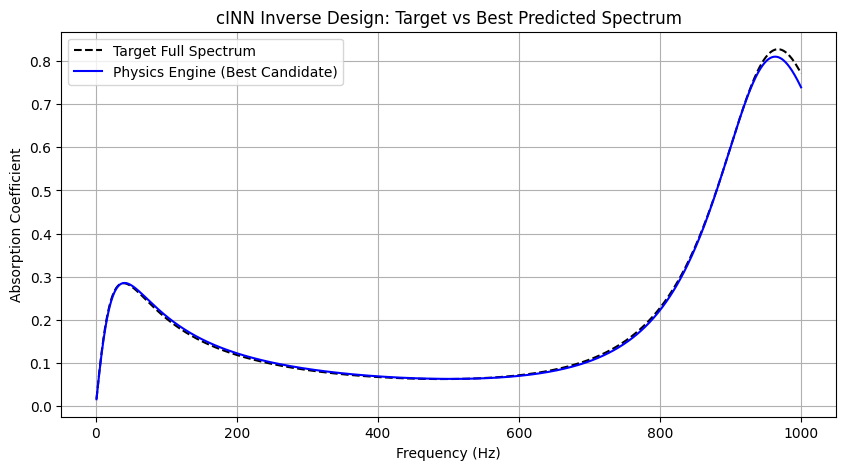

In [15]:
# %%
def inverse_design_cinn(target_spectrum, model, scaler, num_candidates=20):
    model.eval()

    target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_candidates, 1).to(device)
    z_random = torch.randn(num_candidates, 20).to(device)

    with torch.no_grad():
        generated_norm = model(z_random, target_tensor, rev=True)

    generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
    generated_params = validate_and_clip_parameters(generated_params)

    print(f"Evaluating {num_candidates} cINN generated candidates through physics engine...")
    simulated_spectra = batch_physics_evaluation(generated_params, batch_size=num_candidates)

    rmses = np.sqrt(np.mean((simulated_spectra - target_spectrum) ** 2, axis=1))
    best_idx = np.argmin(rmses)

    return generated_params[best_idx], simulated_spectra[best_idx], rmses[best_idx]


# Execute test
test_target = Y_test[0]
best_params, best_pred_spectrum, rmse = inverse_design_cinn(test_target, model, scaler_params, num_candidates=20)

# Visualize result
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, 1001), test_target, label='Target Full Spectrum', color='black', linestyle='--')
plt.plot(np.arange(1, 1001), best_pred_spectrum, label='Physics Engine (Best Candidate)', color='blue')
plt.title('cINN Inverse Design: Target vs Best Predicted Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorption Coefficient')
plt.legend()
plt.grid(True)
plt.show()

# 6. Comprehensive evaluation on test set(1,00,000 rows and 20 candidates for each) and validation of physics engine


COMPREHENSIVE TEST SET EVALUATION

EVALUATING TEST SET (100,000 samples | 20 candidates per sample)
Processing sample 1/100000...
Processing sample 1000/100000...
Processing sample 2000/100000...
Processing sample 3000/100000...
Processing sample 4000/100000...
Processing sample 5000/100000...
Processing sample 6000/100000...
Processing sample 7000/100000...
Processing sample 8000/100000...
Processing sample 9000/100000...
Processing sample 10000/100000...
Processing sample 11000/100000...
Processing sample 12000/100000...
Processing sample 13000/100000...
Processing sample 14000/100000...
Processing sample 15000/100000...
Processing sample 16000/100000...
Processing sample 17000/100000...
Processing sample 18000/100000...
Processing sample 19000/100000...
Processing sample 20000/100000...
Processing sample 21000/100000...
Processing sample 22000/100000...
Processing sample 23000/100000...
Processing sample 24000/100000...
Processing sample 25000/100000...
Processing sample 26000/1000

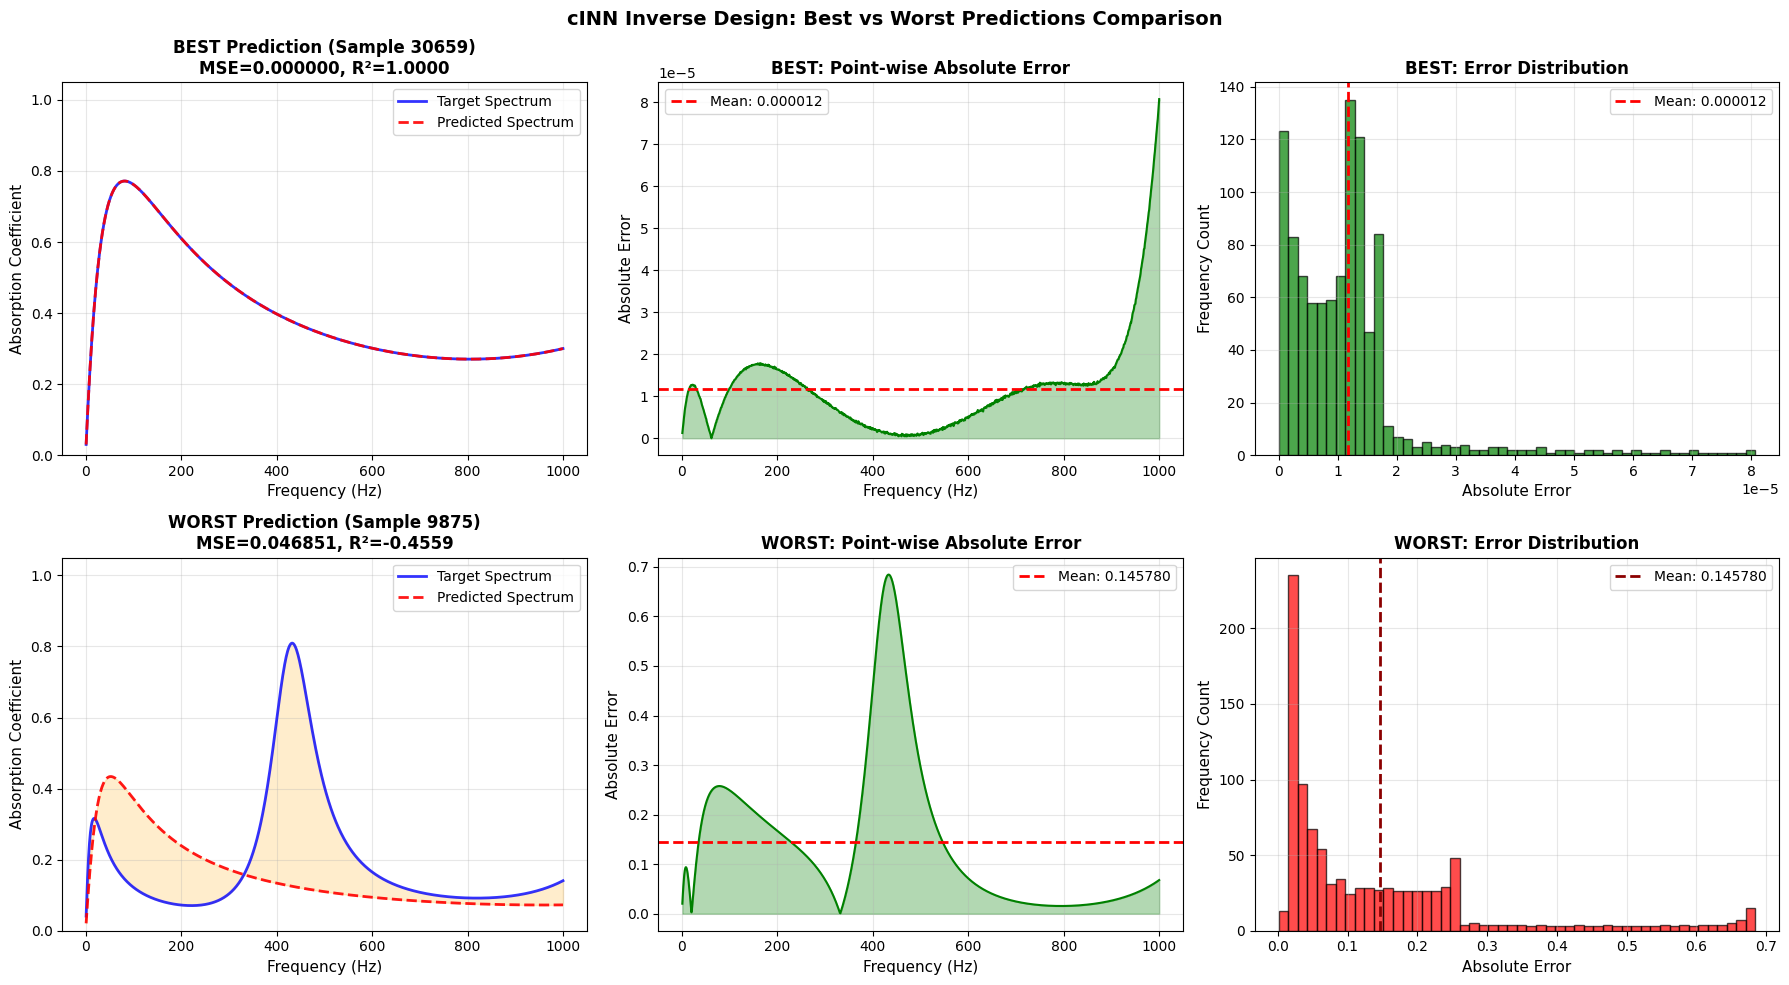

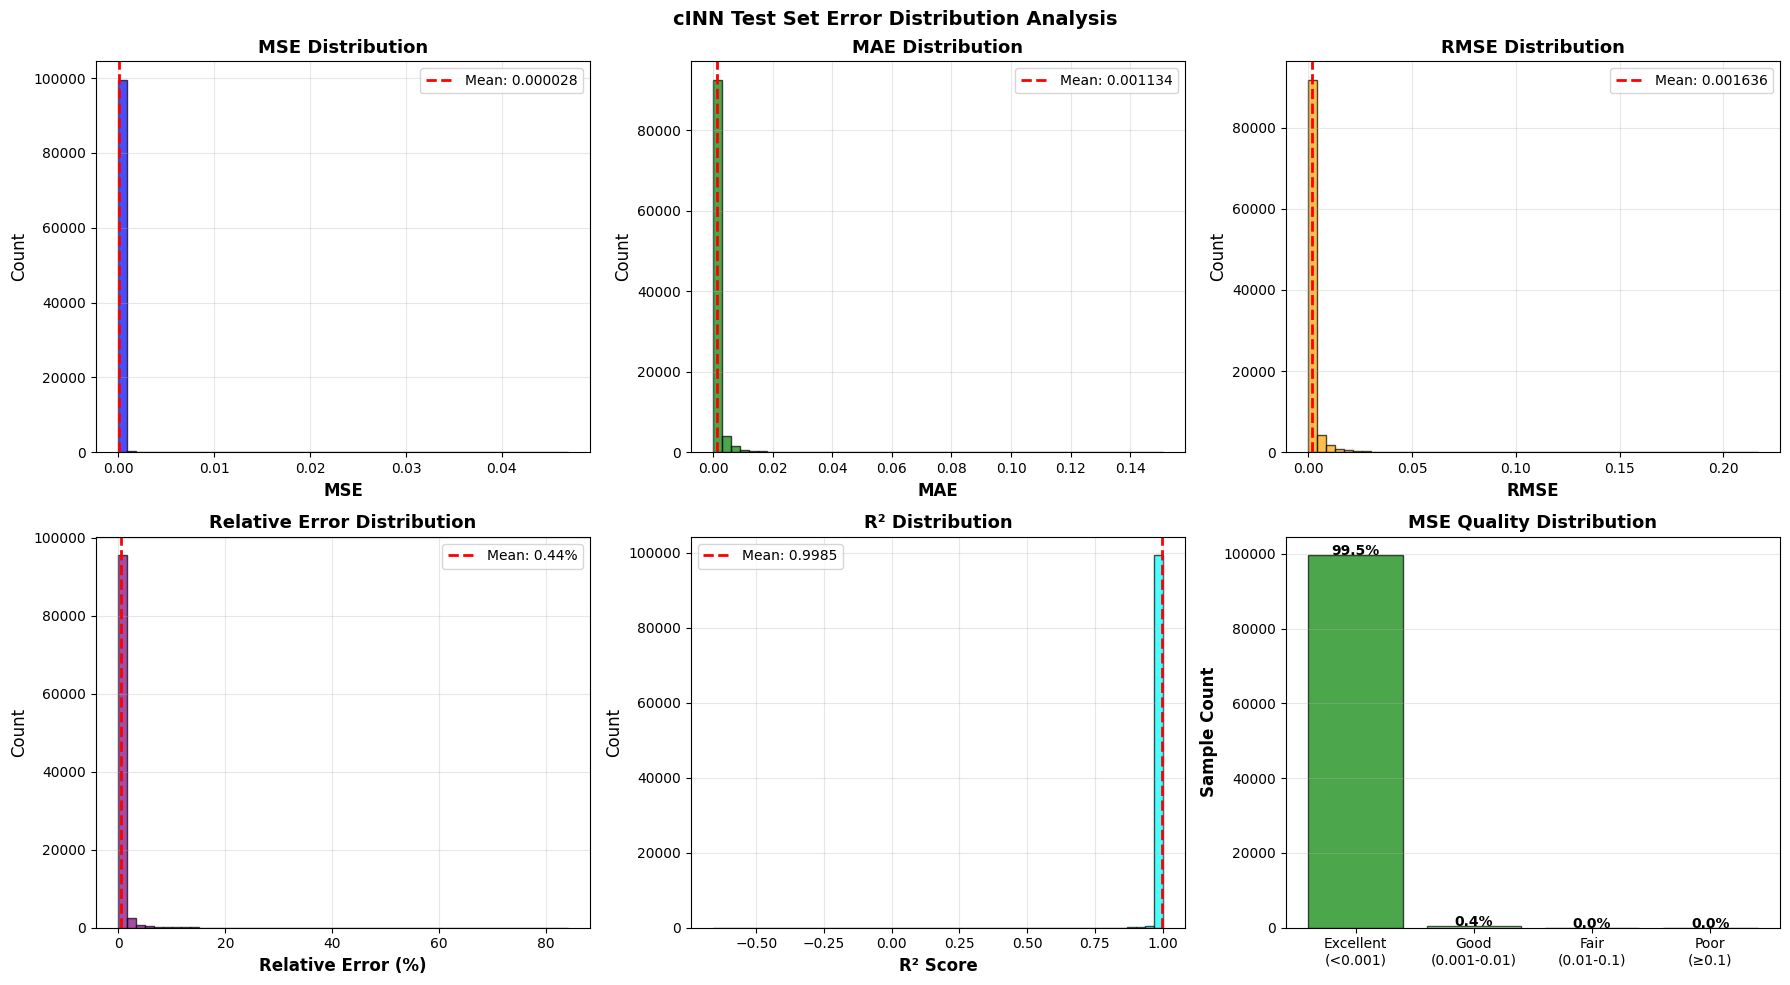


5️⃣  FREQUENCY-WISE RELATIVE ERROR ANALYSIS

📊 Frequency-wise Statistics (Averaged across 100000 test samples):
   ┌─────────────────────────────────────────────────┐
   │ Overall Mean Relative Error:          0.4393% │
   │ Overall Median Relative Error:        0.3474% │
   │ Overall Std Dev:                      2.0045% │
   │ Min Frequency Error:                  0.1800% │
   │ Max Frequency Error:                  1.1740% │
   └─────────────────────────────────────────────────┘

🔍 Frequency Ranges with Highest Errors:
   Top 10% error frequencies (>0.66%):
   ├─  901 - 1000 Hz  (Avg:   0.85%)

📈 Generating frequency-wise error visualization...


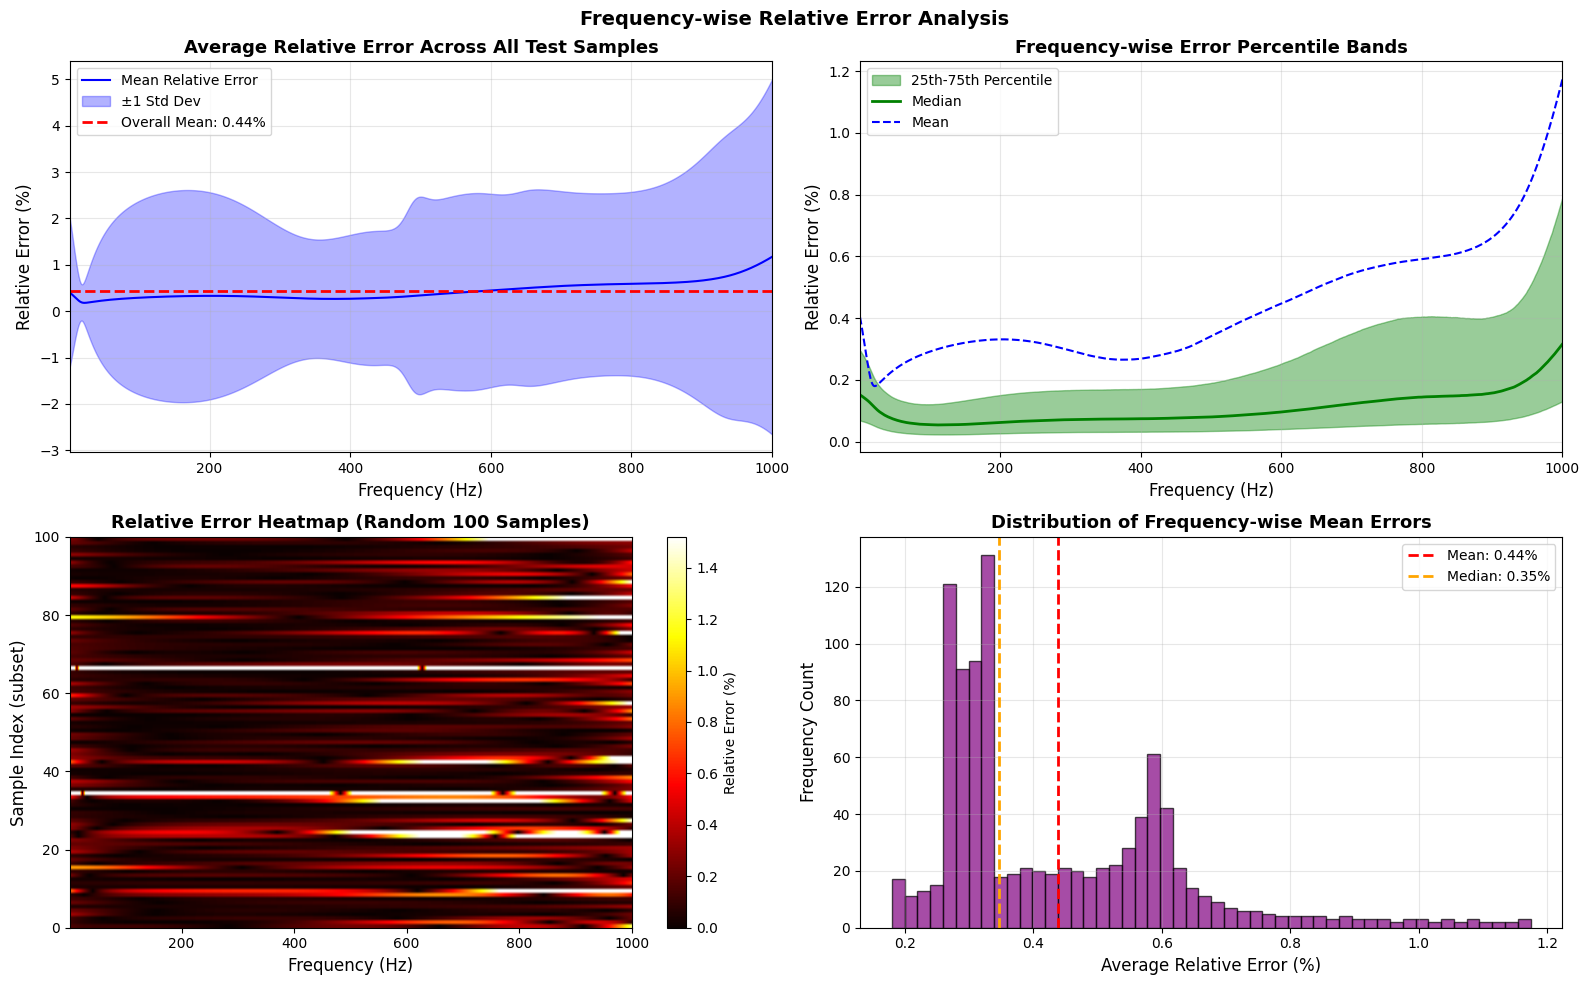


6️⃣  PHYSICS ENGINE VALIDATION (vs Theoretical Model)

📊 Validating physics engine on 100 test predictions...
   Validating sample 20/100...
   Validating sample 40/100...
   Validating sample 60/100...
   Validating sample 80/100...
   Validating sample 100/100...

PHYSICS ENGINE vs THEORETICAL MODEL VALIDATION

📊 Mean Absolute Error (MAE):
   ┌─────────────────────────────────────────┐
   │ Mean:                    0.0000000983 │
   │ Median:                  0.0000000985 │
   │ Min:                     0.0000000642 │
   │ Max:                     0.0000001863 │
   └─────────────────────────────────────────┘

📊 Maximum Point-wise Error:
   ┌─────────────────────────────────────────┐
   │ Mean:                    0.0000004095 │
   │ Max:                     0.0000009438 │
   └─────────────────────────────────────────┘

🔍 VALIDATION RESULT: ✅ VERY GOOD - Negligible differences
   Average MAE: 9.83e-08


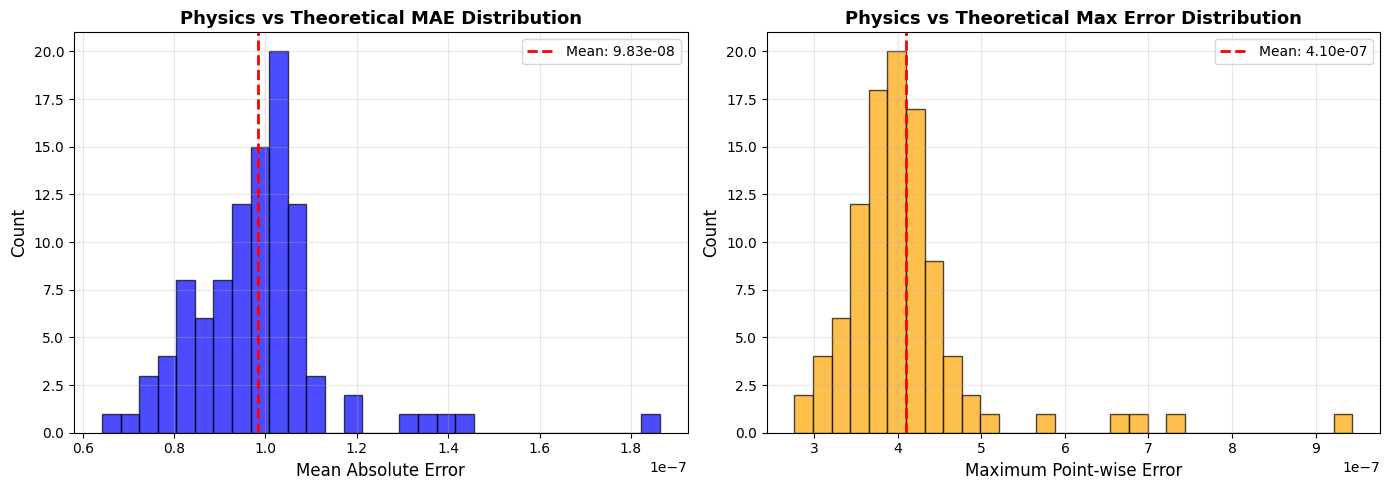


📊 FINAL PERFORMANCE SUMMARY

   🎯 Overall Model Quality: EXCELLENT
   📊 Samples Evaluated: 100,000
   ✅ Samples with MSE < 0.01: 99,979 (100.0%)
   ✅ Samples with R² > 0.9: 99,734 (99.7%)
   📈 Average Frequency-wise Error: 0.44%
   🔬 Physics Engine Validation: Negligible differences

✅ COMPREHENSIVE EVALUATION COMPLETE


In [16]:
# ### 6. Comprehensive Evaluation on Test Set

def calculate_spectral_metrics(target_spectrum, predicted_spectrum):
    """Calculate comprehensive spectral evaluation metrics."""
    epsilon = 1e-8
    
    mse = np.mean((predicted_spectrum - target_spectrum) ** 2)
    mae = np.mean(np.abs(predicted_spectrum - target_spectrum))
    rmse = np.sqrt(mse)
    
    relative_errors = np.abs(predicted_spectrum - target_spectrum) / (np.abs(target_spectrum) + epsilon)
    mean_relative_error = np.mean(relative_errors) * 100
    
    max_error = np.max(np.abs(predicted_spectrum - target_spectrum))
    
    ss_res = np.sum((target_spectrum - predicted_spectrum) ** 2)
    ss_tot = np.sum((target_spectrum - np.mean(target_spectrum)) ** 2)
    r2 = 1 - (ss_res / (ss_tot + epsilon))
    
    return {
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'relative_error': mean_relative_error,
        'max_error': max_error,
        'r2': r2
    }


def evaluate_test_set_cinn(model, scaler, X_test, Y_test, num_candidates=20, num_samples=None):
    """Comprehensive evaluation on test set using cINN."""
    model.eval()
    
    if num_samples is not None:
        eval_samples = min(num_samples, len(Y_test))
    else:
        eval_samples = len(Y_test)
        
    # Define physical bounds for OOB checking
    lower_bounds = np.array([1.0]*10 + [20.0]*6 + [1000.0, 0.1, 1e7, 0.4])
    upper_bounds = np.array([20.0]*10 + [1980.0]*6 + [1500.0, 0.8, 1e8, 0.49])
    
    results = {
        'spectrum_mse': [],
        'spectrum_mae': [],
        'spectrum_rmse': [],
        'spectrum_relative_error': [],
        'spectrum_max_error': [],
        'spectrum_r2': [],
        'all_predictions': [],
        'frequency_wise_errors': [],  
        # NEW HONEST METRICS
        'avg_candidate_rmse': [], 
        'best_candidate_rmse': [],
        'hit_rate': [], 
        'oob_rate': [] 
    }
    
    print(f"\n{'='*70}")
    print(f"EVALUATING TEST SET ({eval_samples:,} samples | {num_candidates} candidates per sample)")
    print(f"{'='*70}")
    
    for idx in range(eval_samples):
        if (idx + 1) % 1000 == 0 or idx == 0:
            print(f"Processing sample {idx+1}/{eval_samples}...")
        
        target_spectrum = Y_test[idx]
        
        target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_candidates, 1).to(device)
        z_random = torch.randn(num_candidates, 20).to(device)
        
        with torch.no_grad():
            generated_norm = model(z_random, target_tensor, rev=True)
        
        # 1. Inverse transform to raw physical units
        generated_params_raw = scaler.inverse_transform(generated_norm.cpu().numpy())
        
        # 2. Track Out-of-Bounds (OOB) Rate BEFORE clipping
        oob_mask = (generated_params_raw < lower_bounds) | (generated_params_raw > upper_bounds)
        sample_oob_rate = np.mean(oob_mask) * 100 
        
        # 3. Clip parameters to strictly valid physical boundaries
        generated_params = validate_and_clip_parameters(generated_params_raw)
        
        # 4. Simulate ALL candidates
        simulated_spectra = batch_physics_evaluation(generated_params)
        
        # 5. Calculate honest candidate distribution metrics
        all_rmses = np.sqrt(np.mean((simulated_spectra - target_spectrum) ** 2, axis=1))
        avg_rmse = np.mean(all_rmses)
        hit_rate = np.mean(all_rmses < 0.05) * 100
        
        # 6. Extract the optimal candidate for the classic visualizations
        best_idx = np.argmin(all_rmses)
        best_spectrum = simulated_spectra[best_idx]
        metrics = calculate_spectral_metrics(target_spectrum, best_spectrum)
        
        results['spectrum_mse'].append(metrics['mse'])
        results['spectrum_mae'].append(metrics['mae'])
        results['spectrum_rmse'].append(metrics['rmse'])
        results['spectrum_relative_error'].append(metrics['relative_error'])
        results['spectrum_max_error'].append(metrics['max_error'])
        results['spectrum_r2'].append(metrics['r2'])
        results['all_predictions'].append((target_spectrum, best_spectrum, generated_params[best_idx]))
        
        results['avg_candidate_rmse'].append(avg_rmse)
        results['best_candidate_rmse'].append(all_rmses[best_idx])
        results['hit_rate'].append(hit_rate)
        results['oob_rate'].append(sample_oob_rate)
        
        epsilon = 1e-8
        freq_rel_error = np.abs(best_spectrum - target_spectrum) / (np.abs(target_spectrum) + epsilon) * 100
        results['frequency_wise_errors'].append(freq_rel_error)
    
    return results


# ============================================================================
# RUN EVALUATION 
# ============================================================================
print("\n" + "="*70)
print("COMPREHENSIVE TEST SET EVALUATION")
print("="*70)

# Evaluating entire test set (num_samples=None) with 20 candidates
test_results = evaluate_test_set_cinn(
    model, scaler_params, X_test, Y_test, 
    num_candidates=20,     
    num_samples=None       
)

# ============================================================================
# DETAILED RESULTS ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE TEST SET RESULTS")
print("="*80)

mse_errors = np.array(test_results['spectrum_mse'])
mae_errors = np.array(test_results['spectrum_mae'])
rmse_errors = np.array(test_results['spectrum_rmse'])
rel_errors = np.array(test_results['spectrum_relative_error'])
max_errors = np.array(test_results['spectrum_max_error'])
r2_scores = np.array(test_results['spectrum_r2'])

oob_rates = np.array(test_results['oob_rate'])
hit_rates = np.array(test_results['hit_rate'])
avg_candidate_rmses = np.array(test_results['avg_candidate_rmse'])

best_sample_idx = np.argmin(mse_errors)
worst_sample_idx = np.argmax(mse_errors)

print(f"\n📊 Dataset Size: {len(mse_errors):,} test samples evaluated")

# ============================================================================
# 0. CANDIDATE GENERATION & PHYSICAL BOUNDARY METRICS
# ============================================================================
print(f"\n" + "="*80)
print(f"0️⃣  HONEST CANDIDATE GENERATION METRICS")
print(f"="*80)
print(f"\n🔬 Physical Violation Rate (Out-of-Bounds %):")
print(f"   Mean OOB Rate: {np.mean(oob_rates):.2f}% of raw generated parameters")

print(f"\n🎯 Average Candidate Performance (All 20 candidates per sample):")
print(f"   Mean Expected RMSE:   {np.mean(avg_candidate_rmses):.6f}")

print(f"\n✅ Candidate Hit Rate (Candidates achieving RMSE < 0.05):")
print(f"   Average Hit Rate:     {np.mean(hit_rates):.1f}%")

# ============================================================================
# 1. OVERALL PERFORMANCE (BEST CANDIDATE)
# ============================================================================
print(f"\n" + "="*80)
print(f"1️⃣  OVERALL PERFORMANCE - TEST SET (OPTIMAL CANDIDATE)")
print(f"="*80)

print(f"\n📈 Spectral Mean Squared Error (MSE):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {mse_errors.mean():>24.8f} │")
print(f"   │ Median:      {np.median(mse_errors):>24.8f} │")
print(f"   │ Std Dev:     {mse_errors.std():>24.8f} │")
print(f"   │ Min:         {mse_errors.min():>24.8f} │")
print(f"   │ Max:         {mse_errors.max():>24.8f} │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📊 Spectral Mean Absolute Error (MAE):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {mae_errors.mean():>24.8f} │")
print(f"   │ Median:      {np.median(mae_errors):>24.8f} │")
print(f"   │ Std Dev:     {mae_errors.std():>24.8f} │")
print(f"   │ Min:         {mae_errors.min():>24.8f} │")
print(f"   │ Max:         {mae_errors.max():>24.8f} │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📉 Full-Curve Root Mean Square Error (RMSE):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {rmse_errors.mean():>24.8f} │")
print(f"   │ Median:      {np.median(rmse_errors):>24.8f} │")
print(f"   │ Std Dev:     {rmse_errors.std():>24.8f} │")
print(f"   │ Min:         {rmse_errors.min():>24.8f} │")
print(f"   │ Max:         {rmse_errors.max():>24.8f} │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📈 Spectral Relative Error (%):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {rel_errors.mean():>23.4f}% │")
print(f"   │ Median:      {np.median(rel_errors):>23.4f}% │")
print(f"   │ Std Dev:     {rel_errors.std():>23.4f}% │")
print(f"   │ Min:         {rel_errors.min():>23.4f}% │")
print(f"   │ Max:         {rel_errors.max():>23.4f}% │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📊 R-squared (R²) Coefficient:")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {r2_scores.mean():>24.6f} │")
print(f"   │ Median:      {np.median(r2_scores):>24.6f} │")
print(f"   │ Std Dev:     {r2_scores.std():>24.6f} │")
print(f"   │ Min:         {r2_scores.min():>24.6f} │")
print(f"   │ Max:         {r2_scores.max():>24.6f} │")
print(f"   └─────────────────────────────────────────┘")

# ============================================================================
# 2. BEST AND WORST SAMPLE METRICS
# ============================================================================
target_best, predicted_best, _ = test_results['all_predictions'][best_sample_idx]
target_worst, predicted_worst, _ = test_results['all_predictions'][worst_sample_idx]
metrics_best = calculate_spectral_metrics(target_best, predicted_best)
metrics_worst = calculate_spectral_metrics(target_worst, predicted_worst)

print(f"\n" + "="*80)
print(f"2️⃣  BEST PERFORMING SAMPLE (Lowest MSE) - Index: {best_sample_idx}")
print(f"="*80)
print(f"   │ MSE:              {metrics_best['mse']:>20.8f} │")
print(f"   │ MAE:              {metrics_best['mae']:>20.8f} │")
print(f"   │ RMSE:             {metrics_best['rmse']:>20.8f} │")
print(f"   │ Relative Error:   {metrics_best['relative_error']:>19.4f}% │")
print(f"   │ R²:               {metrics_best['r2']:>20.6f} │")

print(f"\n" + "="*80)
print(f"3️⃣  WORST PERFORMING SAMPLE (Highest MSE) - Index: {worst_sample_idx}")
print(f"="*80)
print(f"   │ MSE:              {metrics_worst['mse']:>20.8f} │")
print(f"   │ MAE:              {metrics_worst['mae']:>20.8f} │")
print(f"   │ RMSE:             {metrics_worst['rmse']:>20.8f} │")
print(f"   │ Relative Error:   {metrics_worst['relative_error']:>19.4f}% │")
print(f"   │ R²:               {metrics_worst['r2']:>20.6f} │")

# ============================================================================
# 3. ERROR DISTRIBUTION ANALYSIS
# ============================================================================
print(f"\n" + "="*80)
print(f"4️⃣  ERROR DISTRIBUTION ANALYSIS")
print(f"="*80)

excellent = np.sum(mse_errors < 0.001)
good = np.sum((mse_errors >= 0.001) & (mse_errors < 0.01))
fair = np.sum((mse_errors >= 0.01) & (mse_errors < 0.1))
poor = np.sum(mse_errors >= 0.1)

print(f"\n   MSE-based Quality Distribution:")
print(f"   ┌───────────────────────────────────────────────────────┐")
print(f"   │ Excellent (MSE < 0.001):   {excellent:>6d} ({100*excellent/len(mse_errors):>5.1f}%)  │")
print(f"   │ Good (0.001 ≤ MSE < 0.01): {good:>6d} ({100*good/len(mse_errors):>5.1f}%)  │")
print(f"   │ Fair (0.01 ≤ MSE < 0.1):   {fair:>6d} ({100*fair/len(mse_errors):>5.1f}%)  │")
print(f"   │ Poor (MSE ≥ 0.1):          {poor:>6d} ({100*poor/len(mse_errors):>5.1f}%)  │")
print(f"   └───────────────────────────────────────────────────────┘")

# ============================================================================
# 4. VISUALIZATION: BEST AND WORST PREDICTIONS
# ============================================================================
frequencies = np.arange(1, 1001)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ----- BEST PREDICTION -----
ax = axes[0, 0]
ax.plot(frequencies, target_best, 'b-', linewidth=2, label='Target Spectrum', alpha=0.8)
ax.plot(frequencies, predicted_best, 'r--', linewidth=2, label='Predicted Spectrum', alpha=0.9)
ax.fill_between(frequencies, target_best, predicted_best, alpha=0.2, color='orange')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Absorption Coefficient', fontsize=11)
ax.set_title(f'BEST Prediction (Sample {best_sample_idx})\nMSE={metrics_best["mse"]:.6f}, R²={metrics_best["r2"]:.4f}', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

ax = axes[0, 1]
abs_error_best = np.abs(predicted_best - target_best)
ax.plot(frequencies, abs_error_best, 'g-', linewidth=1.5)
ax.fill_between(frequencies, 0, abs_error_best, alpha=0.3, color='green')
ax.axhline(y=np.mean(abs_error_best), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(abs_error_best):.6f}')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Absolute Error', fontsize=11)
ax.set_title('BEST: Point-wise Absolute Error', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.hist(abs_error_best, bins=50, color='green', alpha=0.7, edgecolor='black')
ax.axvline(x=np.mean(abs_error_best), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(abs_error_best):.6f}')
ax.set_xlabel('Absolute Error', fontsize=11)
ax.set_ylabel('Frequency Count', fontsize=11)
ax.set_title('BEST: Error Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ----- WORST PREDICTION -----
ax = axes[1, 0]
ax.plot(frequencies, target_worst, 'b-', linewidth=2, label='Target Spectrum', alpha=0.8)
ax.plot(frequencies, predicted_worst, 'r--', linewidth=2, label='Predicted Spectrum', alpha=0.9)
ax.fill_between(frequencies, target_worst, predicted_worst, alpha=0.2, color='orange')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Absorption Coefficient', fontsize=11)
ax.set_title(f'WORST Prediction (Sample {worst_sample_idx})\nMSE={metrics_worst["mse"]:.6f}, R²={metrics_worst["r2"]:.4f}', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

ax = axes[1, 1]
abs_error_worst = np.abs(predicted_worst - target_worst)
ax.plot(frequencies, abs_error_worst, 'g-', linewidth=1.5)
ax.fill_between(frequencies, 0, abs_error_worst, alpha=0.3, color='green')
ax.axhline(y=np.mean(abs_error_worst), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(abs_error_worst):.6f}')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Absolute Error', fontsize=11)
ax.set_title('WORST: Point-wise Absolute Error', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.hist(abs_error_worst, bins=50, color='red', alpha=0.7, edgecolor='black')
ax.axvline(x=np.mean(abs_error_worst), color='darkred', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(abs_error_worst):.6f}')
ax.set_xlabel('Absolute Error', fontsize=11)
ax.set_ylabel('Frequency Count', fontsize=11)
ax.set_title('WORST: Error Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('cINN Inverse Design: Best vs Worst Predictions Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 5. ERROR DISTRIBUTIONS ACROSS TEST SET
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
ax.hist(mse_errors, bins=50, color='blue', alpha=0.7, edgecolor='black')
ax.axvline(x=mse_errors.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {mse_errors.mean():.6f}')
ax.set_xlabel('MSE', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('MSE Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.hist(mae_errors, bins=50, color='green', alpha=0.7, edgecolor='black')
ax.axvline(x=mae_errors.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {mae_errors.mean():.6f}')
ax.set_xlabel('MAE', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('MAE Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.hist(rmse_errors, bins=50, color='orange', alpha=0.7, edgecolor='black')
ax.axvline(x=rmse_errors.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {rmse_errors.mean():.6f}')
ax.set_xlabel('RMSE', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('RMSE Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.hist(rel_errors, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(x=rel_errors.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {rel_errors.mean():.2f}%')
ax.set_xlabel('Relative Error (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Relative Error Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.hist(r2_scores, bins=50, color='cyan', alpha=0.7, edgecolor='black')
ax.axvline(x=r2_scores.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {r2_scores.mean():.4f}')
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('R² Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
categories = ['Excellent\n(<0.001)', 'Good\n(0.001-0.01)', 'Fair\n(0.01-0.1)', 'Poor\n(≥0.1)']
counts = [excellent, good, fair, poor]
colors = ['green', 'lightgreen', 'orange', 'red']
ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Sample Count', fontsize=12, fontweight='bold')
ax.set_title('MSE Quality Distribution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, (count, pct) in enumerate(zip(counts, [100*c/len(mse_errors) for c in counts])):
    ax.text(i, count + 1, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('cINN Test Set Error Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 6. FREQUENCY-WISE RELATIVE ERROR ANALYSIS (NEW SECTION)
# ============================================================================
print(f"\n" + "="*80)
print(f"5️⃣  FREQUENCY-WISE RELATIVE ERROR ANALYSIS")
print(f"="*80)

# Compute average relative error across all test samples for each frequency
frequency_wise_errors = np.array(test_results['frequency_wise_errors'])  # Shape: (num_samples, 1000)
avg_freq_rel_error = np.mean(frequency_wise_errors, axis=0)  # Shape: (1000,)
std_freq_rel_error = np.std(frequency_wise_errors, axis=0)
median_freq_rel_error = np.median(frequency_wise_errors, axis=0)
percentile_25_freq = np.percentile(frequency_wise_errors, 25, axis=0)
percentile_75_freq = np.percentile(frequency_wise_errors, 75, axis=0)

print(f"\n📊 Frequency-wise Statistics (Averaged across {len(frequency_wise_errors)} test samples):")
print(f"   ┌─────────────────────────────────────────────────┐")
print(f"   │ Overall Mean Relative Error:    {np.mean(avg_freq_rel_error):>12.4f}% │")
print(f"   │ Overall Median Relative Error:  {np.median(avg_freq_rel_error):>12.4f}% │")
print(f"   │ Overall Std Dev:                {np.mean(std_freq_rel_error):>12.4f}% │")
print(f"   │ Min Frequency Error:            {avg_freq_rel_error.min():>12.4f}% │")
print(f"   │ Max Frequency Error:            {avg_freq_rel_error.max():>12.4f}% │")
print(f"   └─────────────────────────────────────────────────┘")

# Identify problematic frequency ranges
print(f"\n🔍 Frequency Ranges with Highest Errors:")
high_error_threshold = np.percentile(avg_freq_rel_error, 90)
high_error_freqs = np.where(avg_freq_rel_error > high_error_threshold)[0] + 1  # +1 for 1-based indexing

if len(high_error_freqs) > 0:
    print(f"   Top 10% error frequencies (>{high_error_threshold:.2f}%):")
    freq_ranges = []
    start = high_error_freqs[0]
    for i in range(1, len(high_error_freqs)):
        if high_error_freqs[i] != high_error_freqs[i-1] + 1:
            freq_ranges.append((start, high_error_freqs[i-1]))
            start = high_error_freqs[i]
    freq_ranges.append((start, high_error_freqs[-1]))
    
    for start_f, end_f in freq_ranges[:5]:  # Show first 5 ranges
        avg_error_in_range = avg_freq_rel_error[start_f-1:end_f].mean()
        print(f"   ├─ {start_f:4d} - {end_f:4d} Hz  (Avg: {avg_error_in_range:6.2f}%)")

# Visualization
print(f"\n📈 Generating frequency-wise error visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Average Relative Error vs Frequency
ax = axes[0, 0]
ax.plot(frequencies, avg_freq_rel_error, 'b-', linewidth=1.5, label='Mean Relative Error')
ax.fill_between(frequencies, 
                 avg_freq_rel_error - std_freq_rel_error, 
                 avg_freq_rel_error + std_freq_rel_error, 
                 alpha=0.3, color='blue', label='±1 Std Dev')
ax.axhline(y=np.mean(avg_freq_rel_error), color='r', linestyle='--', linewidth=2, 
           label=f'Overall Mean: {np.mean(avg_freq_rel_error):.2f}%')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Relative Error (%)', fontsize=12)
ax.set_title('Average Relative Error Across All Test Samples', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 1000])

# Plot 2: Percentile Bands
ax = axes[0, 1]
ax.fill_between(frequencies, percentile_25_freq, percentile_75_freq, alpha=0.4, color='green', label='25th-75th Percentile')
ax.plot(frequencies, median_freq_rel_error, 'g-', linewidth=2, label='Median')
ax.plot(frequencies, avg_freq_rel_error, 'b--', linewidth=1.5, label='Mean')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Relative Error (%)', fontsize=12)
ax.set_title('Frequency-wise Error Percentile Bands', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 1000])

# Plot 3: Heatmap of errors across samples
ax = axes[1, 0]
sample_indices = np.random.choice(len(frequency_wise_errors), min(100, len(frequency_wise_errors)), replace=False)
im = ax.imshow(frequency_wise_errors[sample_indices], aspect='auto', cmap='hot', 
               extent=[1, 1000, 0, len(sample_indices)], vmin=0, vmax=np.percentile(frequency_wise_errors, 95))
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Sample Index (subset)', fontsize=12)
ax.set_title(f'Relative Error Heatmap (Random {len(sample_indices)} Samples)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Relative Error (%)')

# Plot 4: Histogram of average frequency errors
ax = axes[1, 1]
ax.hist(avg_freq_rel_error, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(x=np.mean(avg_freq_rel_error), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(avg_freq_rel_error):.2f}%')
ax.axvline(x=np.median(avg_freq_rel_error), color='orange', linestyle='--', linewidth=2, 
           label=f'Median: {np.median(avg_freq_rel_error):.2f}%')
ax.set_xlabel('Average Relative Error (%)', fontsize=12)
ax.set_ylabel('Frequency Count', fontsize=12)
ax.set_title('Distribution of Frequency-wise Mean Errors', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Frequency-wise Relative Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 7. PHYSICS ENGINE VALIDATION vs THEORETICAL MODEL (NEW SECTION)
# ============================================================================
print(f"\n" + "="*80)
print(f"6️⃣  PHYSICS ENGINE VALIDATION (vs Theoretical Model)")
print(f"="*80)

def theoretical_model_full_spectrum(params):
    """Calculate absorption using theoretical TMM (reference implementation)."""
    d_layers = params[0:10]  # mm
    m_values_arr = params[10:16]  # mm
    rho_rubber = params[16]
    eta = params[17]
    E_real = params[18]
    nu = params[19]
    
    W = 2.0  # meters
    rho_water, c_water = 1000.0, 1500.0
    Z_water = rho_water * c_water
    
    d_list = [d / 1000.0 for d in d_layers]
    m_dict = {2: m_values_arr[0]/1000.0, 3: m_values_arr[1]/1000.0, 
              5: m_values_arr[2]/1000.0, 6: m_values_arr[3]/1000.0,
              8: m_values_arr[4]/1000.0, 9: m_values_arr[5]/1000.0}
    
    frequencies = np.arange(1, 1001, 1)
    alpha_arr = []
    
    E_rubber = E_real * (1 + 1j * eta)
    lam = (E_rubber * nu) / ((1 + nu) * (1 - 2 * nu))
    mu = E_rubber / (2 * (1 + nu))
    
    for f in frequencies:
        omega = 2 * np.pi * f
        T_total = np.eye(2, dtype=complex)
        
        for i in range(10):
            layer_num = i + 1
            d_i = d_list[i]
            epsilon = (m_dict[layer_num] / W) if layer_num in m_dict else 0.0
            
            rho_eff = rho_rubber * (1 - epsilon**2)
            numerator = (mu * (lam + 2*mu) * (epsilon**2 + 1)) + (2 * (epsilon**2) * lam)
            denominator = ((lam + mu) * epsilon**2) + mu
            
            S_eff = numerator * 1e15 if abs(denominator) < 1e-15 else numerator / denominator
            c_eff = np.sqrt(S_eff / rho_eff)
            k_eff = omega / c_eff
            Z_eff = rho_eff * c_eff
            
            cos_kd, sin_kd = np.cos(k_eff * d_i), np.sin(k_eff * d_i)
            term_21 = 1e15 if abs(Z_eff) < 1e-15 else 1j * sin_kd / Z_eff
            
            T_i = np.array([[cos_kd, 1j * Z_eff * sin_kd], [term_21, cos_kd]], dtype=complex)
            T_total = np.dot(T_total, T_i)
        
        T11, T21 = T_total[0, 0], T_total[1, 0]
        
        if np.abs(T21) < 1e-15:
            Z_in, R = 1e15 + 0j, 1.0 + 0j
        else:
            Z_in = T11 / T21
            R = (Z_in - Z_water) / (Z_in + Z_water) if np.abs(Z_in) <= 1e15 else 1.0 + 0j
        
        alpha = max(0.0, min(1.0, (1 - np.abs(R)**2).real))
        alpha_arr.append(alpha)
    
    return np.array(alpha_arr)

# Validate on subset of test predictions
num_validation_samples = min(100, len(test_results['all_predictions']))
print(f"\n📊 Validating physics engine on {num_validation_samples} test predictions...")

validation_errors = []
for idx in range(num_validation_samples):
    if (idx + 1) % 20 == 0:
        print(f"   Validating sample {idx+1}/{num_validation_samples}...")
    
    _, _, predicted_params = test_results['all_predictions'][idx]
    
    # Physics engine calculation
    physics_spectrum = batch_physics_evaluation(predicted_params.reshape(1, -1))[0]
    
    # Theoretical model calculation
    theoretical_spectrum = theoretical_model_full_spectrum(predicted_params)
    
    # Compute errors
    abs_diff = np.abs(physics_spectrum - theoretical_spectrum)
    mae = np.mean(abs_diff)
    validation_errors.append({
        'mae': mae,
        'max': np.max(abs_diff),
        'rmse': np.sqrt(np.mean((physics_spectrum - theoretical_spectrum)**2))
    })

mae_vals = np.array([e['mae'] for e in validation_errors])
max_vals = np.array([e['max'] for e in validation_errors])
rmse_vals = np.array([e['rmse'] for e in validation_errors])

print(f"\n" + "="*80)
print("PHYSICS ENGINE vs THEORETICAL MODEL VALIDATION")
print("="*80)

print(f"\n📊 Mean Absolute Error (MAE):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {mae_vals.mean():>24.10f} │")
print(f"   │ Median:      {np.median(mae_vals):>24.10f} │")
print(f"   │ Min:         {mae_vals.min():>24.10f} │")
print(f"   │ Max:         {mae_vals.max():>24.10f} │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📊 Maximum Point-wise Error:")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {max_vals.mean():>24.10f} │")
print(f"   │ Max:         {max_vals.max():>24.10f} │")
print(f"   └─────────────────────────────────────────┘")

# Assessment
if mae_vals.mean() < 1e-8:
    status = "✅ EXCELLENT - Perfect agreement"
elif mae_vals.mean() < 1e-6:
    status = "✅ VERY GOOD - Negligible differences"
elif mae_vals.mean() < 1e-4:
    status = "✅ GOOD - Acceptable numerical precision"
else:
    status = "⚠️  WARNING - Notable discrepancies"

print(f"\n🔍 VALIDATION RESULT: {status}")
print(f"   Average MAE: {mae_vals.mean():.2e}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(mae_vals, bins=30, color='blue', alpha=0.7, edgecolor='black')
ax.axvline(x=mae_vals.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {mae_vals.mean():.2e}')
ax.set_xlabel('Mean Absolute Error', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Physics vs Theoretical MAE Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(max_vals, bins=30, color='orange', alpha=0.7, edgecolor='black')
ax.axvline(x=max_vals.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {max_vals.mean():.2e}')
ax.set_xlabel('Maximum Point-wise Error', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Physics vs Theoretical Max Error Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 8. FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("📊 FINAL PERFORMANCE SUMMARY")
print("="*80)

overall_quality = "EXCELLENT" if mse_errors.mean() < 0.001 else \
                  "GOOD" if mse_errors.mean() < 0.01 else \
                  "FAIR" if mse_errors.mean() < 0.1 else "NEEDS IMPROVEMENT"

print(f"\n   🎯 Overall Model Quality: {overall_quality}")
print(f"   📊 Samples Evaluated: {len(mse_errors):,}")
print(f"   ✅ Samples with MSE < 0.01: {excellent + good:,} ({100*(excellent+good)/len(mse_errors):.1f}%)")
print(f"   ✅ Samples with R² > 0.9: {np.sum(r2_scores > 0.9):,} ({100*np.sum(r2_scores > 0.9)/len(r2_scores):.1f}%)")
print(f"   📈 Average Frequency-wise Error: {np.mean(avg_freq_rel_error):.2f}%")
print(f"   🔬 Physics Engine Validation: {status.split('-')[1].strip()}")

print("\n" + "="*80)
print("✅ COMPREHENSIVE EVALUATION COMPLETE")
print("="*80)


🔍 FREQUENCY-WISE ABSORPTION PREDICTION ANALYSIS

🏆 TOP 10 BEST PREDICTED FREQUENCIES (Lowest Average Error):
   ┌───────┬────────────┬─────────────────┐
   │ Rank  │ Frequency  │ Mean Abs. Error │
   ├───────┼────────────┼─────────────────┤
   │  1    │     1 Hz   │    0.000211     │
   │  2    │     2 Hz   │    0.000383     │
   │  3    │   363 Hz   │    0.000487     │
   │  4    │   362 Hz   │    0.000487     │
   │  5    │   364 Hz   │    0.000487     │
   │  6    │   361 Hz   │    0.000487     │
   │  7    │   365 Hz   │    0.000487     │
   │  8    │   360 Hz   │    0.000487     │
   │  9    │   366 Hz   │    0.000488     │
   │  10   │   359 Hz   │    0.000488     │
   └───────┴────────────┴─────────────────┘

🚨 TOP 10 WORST PREDICTED FREQUENCIES (Highest Average Error):
   ┌───────┬────────────┬─────────────────┐
   │ Rank  │ Frequency  │ Mean Abs. Error │
   ├───────┼────────────┼─────────────────┤
   │  1    │  1000 Hz   │    0.003533     │
   │  2    │   999 Hz   │    0.0035

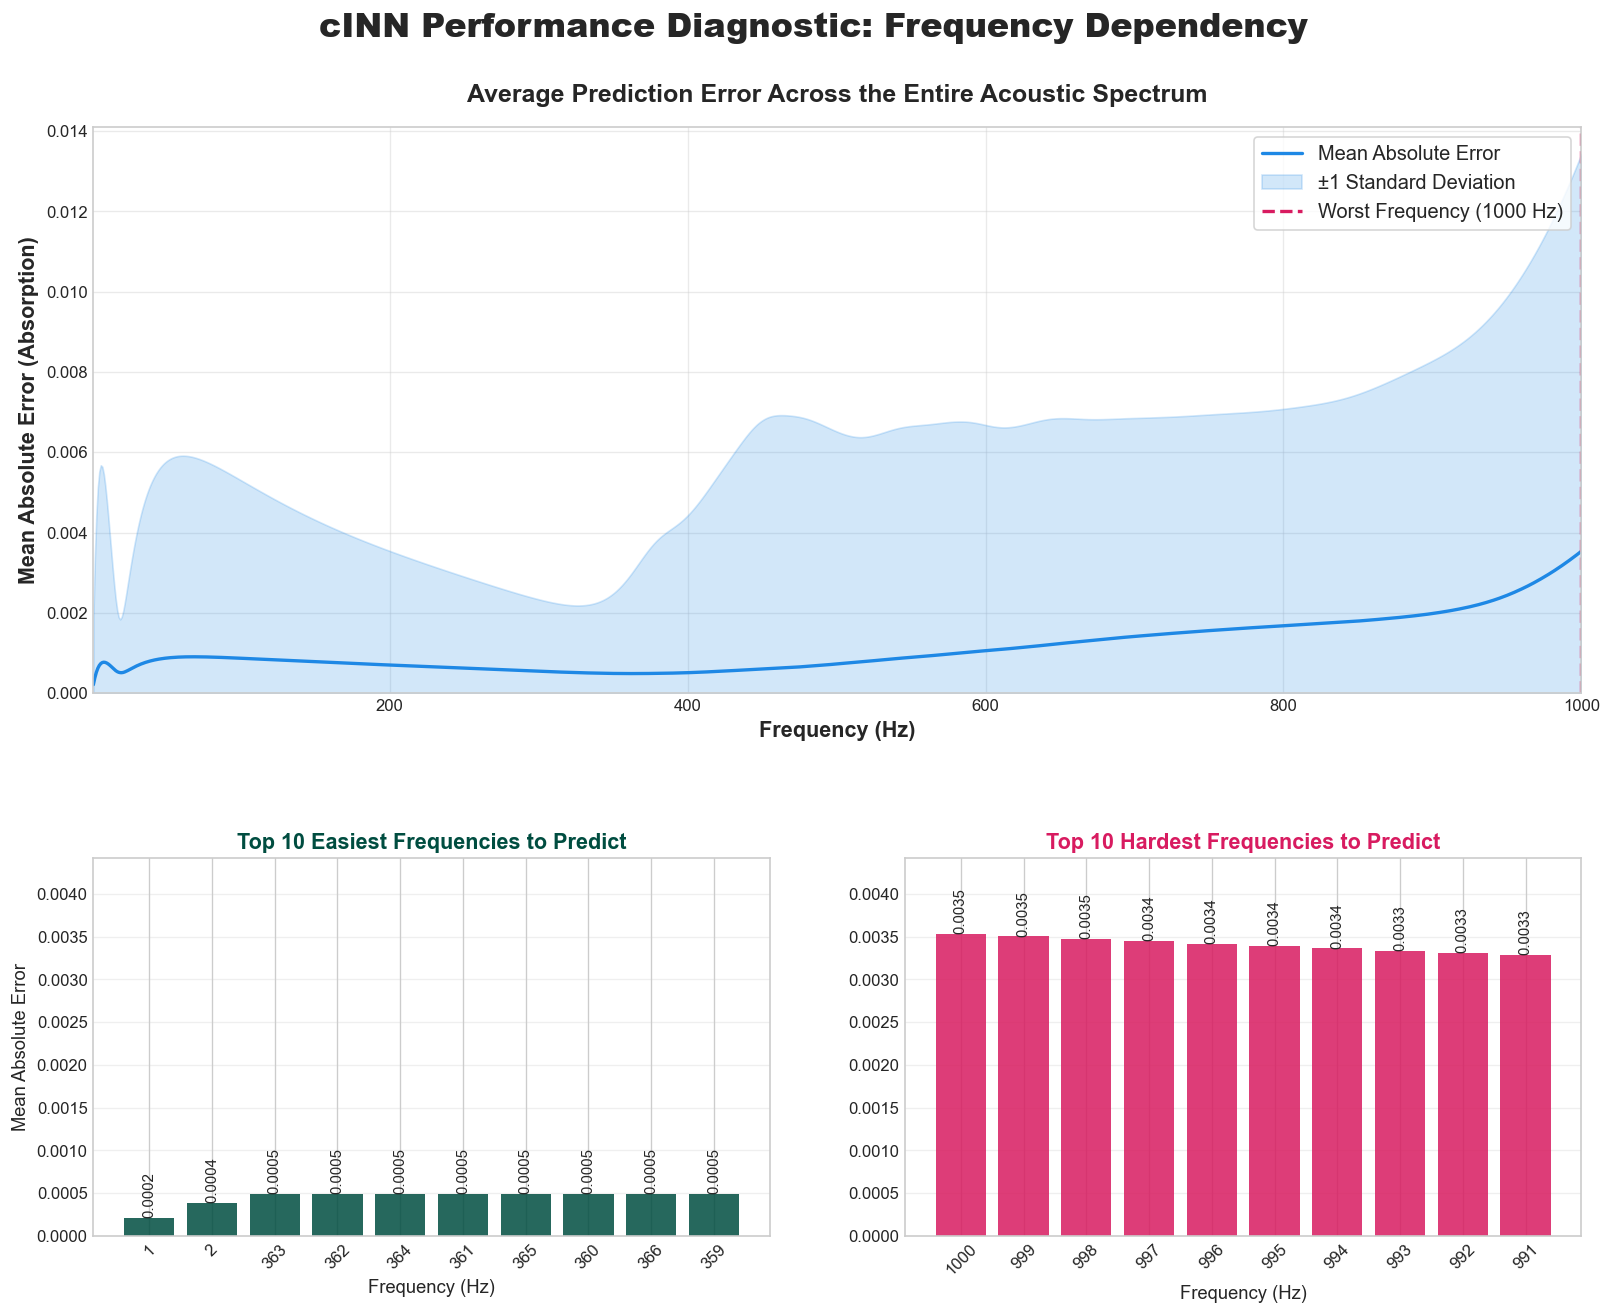

In [17]:
# ============================================================================
# 10. DEEP DIVE: PREDICTION ACCURACY PER FREQUENCY
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

print("\n" + "="*80)
print("🔍 FREQUENCY-WISE ABSORPTION PREDICTION ANALYSIS")
print("="*80)

# 1. Extract all target and predicted spectra from the Phase 6 results
try:
    all_targets = np.array([item[0] for item in test_results['all_predictions']])
    all_predicts = np.array([item[1] for item in test_results['all_predictions']])
    frequencies = np.arange(1, 1001)
except NameError:
    print("❌ ERROR: 'test_results' not found. Please run the Phase 6 Evaluation cell first!")
    raise

# 2. Calculate point-wise Absolute Error for every frequency across all samples
abs_errors = np.abs(all_predicts - all_targets)  # Shape: (num_samples, 1000)
mean_ae_per_freq = np.mean(abs_errors, axis=0)   # Average error at each Hz
std_ae_per_freq = np.std(abs_errors, axis=0)     # Stability/variance at each Hz

# 3. Identify the Best and Worst Frequencies
sorted_indices = np.argsort(mean_ae_per_freq)

best_freqs_idx = sorted_indices[:10]
worst_freqs_idx = sorted_indices[-10:][::-1]  # Reversed so the absolute worst is first

print("\n🏆 TOP 10 BEST PREDICTED FREQUENCIES (Lowest Average Error):")
print("   ┌───────┬────────────┬─────────────────┐")
print("   │ Rank  │ Frequency  │ Mean Abs. Error │")
print("   ├───────┼────────────┼─────────────────┤")
for i, idx in enumerate(best_freqs_idx):
    print(f"   │  {i+1:<2}   │  {frequencies[idx]:>4} Hz   │    {mean_ae_per_freq[idx]:.6f}     │")
print("   └───────┴────────────┴─────────────────┘")

print("\n🚨 TOP 10 WORST PREDICTED FREQUENCIES (Highest Average Error):")
print("   ┌───────┬────────────┬─────────────────┐")
print("   │ Rank  │ Frequency  │ Mean Abs. Error │")
print("   ├───────┼────────────┼─────────────────┤")
for i, idx in enumerate(worst_freqs_idx):
    print(f"   │  {i+1:<2}   │  {frequencies[idx]:>4} Hz   │    {mean_ae_per_freq[idx]:.6f}     │")
print("   └───────┴────────────┴─────────────────┘")

# ============================================================================
# 4. VISUALIZATION
# ============================================================================
fig = plt.figure(figsize=(16, 12), dpi=120)
gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1], hspace=0.35, wspace=0.2)

# --- PLOT A: Full Frequency Spectrum Error ---
ax_main = fig.add_subplot(gs[0, :])
ax_main.plot(frequencies, mean_ae_per_freq, color='#1E88E5', linewidth=2, label='Mean Absolute Error')
ax_main.fill_between(
    frequencies, 
    np.maximum(0, mean_ae_per_freq - std_ae_per_freq), 
    mean_ae_per_freq + std_ae_per_freq, 
    color='#1E88E5', alpha=0.2, label='±1 Standard Deviation'
)
# Highlight the worst frequency region
ax_main.axvline(x=frequencies[worst_freqs_idx[0]], color='#D81B60', linestyle='--', linewidth=2, 
                label=f'Worst Frequency ({frequencies[worst_freqs_idx[0]]} Hz)')

ax_main.set_xlabel('Frequency (Hz)', fontsize=13, fontweight='bold')
ax_main.set_ylabel('Mean Absolute Error (Absorption)', fontsize=13, fontweight='bold')
ax_main.set_title('Average Prediction Error Across the Entire Acoustic Spectrum', fontsize=15, fontweight='bold', pad=15)
ax_main.set_xlim([1, 1000])
ax_main.set_ylim(bottom=0)
ax_main.legend(fontsize=12, loc='upper right', frameon=True)
ax_main.grid(True, alpha=0.4)

# --- PLOT B: Bar Chart of Top 10 Best Frequencies ---
ax_best = fig.add_subplot(gs[1, 0])
best_bars = ax_best.bar([str(f) for f in frequencies[best_freqs_idx]], mean_ae_per_freq[best_freqs_idx], color='#004D40', alpha=0.85)
ax_best.set_title('Top 10 Easiest Frequencies to Predict', fontsize=13, fontweight='bold', color='#004D40')
ax_best.set_xlabel('Frequency (Hz)', fontsize=11)
ax_best.set_ylabel('Mean Absolute Error', fontsize=11)
ax_best.tick_params(axis='x', rotation=45)
ax_best.grid(True, axis='y', alpha=0.3)

# Add exact numbers on top of bars
for bar in best_bars:
    yval = bar.get_height()
    ax_best.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', ha='center', va='bottom', fontsize=9, rotation=90)

# --- PLOT C: Bar Chart of Top 10 Worst Frequencies ---
ax_worst = fig.add_subplot(gs[1, 1])
worst_bars = ax_worst.bar([str(f) for f in frequencies[worst_freqs_idx]], mean_ae_per_freq[worst_freqs_idx], color='#D81B60', alpha=0.85)
ax_worst.set_title('Top 10 Hardest Frequencies to Predict', fontsize=13, fontweight='bold', color='#D81B60')
ax_worst.set_xlabel('Frequency (Hz)', fontsize=11)
ax_worst.tick_params(axis='x', rotation=45)
ax_worst.grid(True, axis='y', alpha=0.3)

# Add exact numbers on top of bars
for bar in worst_bars:
    yval = bar.get_height()
    ax_worst.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', ha='center', va='bottom', fontsize=9, rotation=90)

# Match Y-axis for the two bar charts so they are directly comparable
max_bar_height = max(mean_ae_per_freq[worst_freqs_idx]) * 1.25
ax_best.set_ylim([0, max_bar_height])
ax_worst.set_ylim([0, max_bar_height])

plt.suptitle('cINN Performance Diagnostic: Frequency Dependency', fontsize=20, fontweight='black', y=0.96)
plt.show()

In [18]:
# # ### 6. Comprehensive Evaluation on Test Set

# def calculate_spectral_metrics(target_spectrum, predicted_spectrum):
#     """Calculate comprehensive spectral evaluation metrics."""
#     epsilon = 1e-8
    
#     mse = np.mean((predicted_spectrum - target_spectrum) ** 2)
#     mae = np.mean(np.abs(predicted_spectrum - target_spectrum))
#     rmse = np.sqrt(mse)
    
#     relative_errors = np.abs(predicted_spectrum - target_spectrum) / (np.abs(target_spectrum) + epsilon)
#     mean_relative_error = np.mean(relative_errors) * 100
    
#     max_error = np.max(np.abs(predicted_spectrum - target_spectrum))
    
#     ss_res = np.sum((target_spectrum - predicted_spectrum) ** 2)
#     ss_tot = np.sum((target_spectrum - np.mean(target_spectrum)) ** 2)
#     r2 = 1 - (ss_res / (ss_tot + epsilon))
    
#     return {
#         'mse': mse,
#         'mae': mae,
#         'rmse': rmse,
#         'relative_error': mean_relative_error,
#         'max_error': max_error,
#         'r2': r2
#     }


# def evaluate_test_set_cinn(model, scaler, X_test, Y_test, num_candidates=10, num_samples=None):
#     """Comprehensive evaluation on test set using cINN."""
#     model.eval()
    
#     if num_samples is not None:
#         eval_samples = min(num_samples, len(Y_test))
#     else:
#         eval_samples = len(Y_test)
    
#     results = {
#         'spectrum_mse': [],
#         'spectrum_mae': [],
#         'spectrum_rmse': [],
#         'spectrum_relative_error': [],
#         'spectrum_max_error': [],
#         'spectrum_r2': [],
#         'all_predictions': [],
#         'frequency_wise_errors': [],  # NEW: Store per-frequency errors
#     }
    
#     print(f"\n{'='*70}")
#     print(f"EVALUATING TEST SET ({eval_samples:,} samples)")
#     print(f"{'='*70}")
    
#     for idx in range(eval_samples):
#         if (idx + 1) % 1000 == 0 or idx == 0:
#             print(f"Processing sample {idx+1}/{eval_samples}...")
        
#         target_spectrum = Y_test[idx]
        
#         target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_candidates, 1).to(device)
#         z_random = torch.randn(num_candidates, 20).to(device)
        
#         with torch.no_grad():
#             generated_norm = model(z_random, target_tensor, rev=True)
        
#         generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
#         generated_params = validate_and_clip_parameters(generated_params)
        
#         simulated_spectra = batch_physics_evaluation(generated_params)
        
#         rmses = np.sqrt(np.mean((simulated_spectra - target_spectrum) ** 2, axis=1))
#         best_idx = np.argmin(rmses)
#         best_spectrum = simulated_spectra[best_idx]
        
#         metrics = calculate_spectral_metrics(target_spectrum, best_spectrum)
        
#         results['spectrum_mse'].append(metrics['mse'])
#         results['spectrum_mae'].append(metrics['mae'])
#         results['spectrum_rmse'].append(metrics['rmse'])
#         results['spectrum_relative_error'].append(metrics['relative_error'])
#         results['spectrum_max_error'].append(metrics['max_error'])
#         results['spectrum_r2'].append(metrics['r2'])
#         results['all_predictions'].append((target_spectrum, best_spectrum, generated_params[best_idx]))
        
#         # NEW: Compute frequency-wise relative error
#         epsilon = 1e-8
#         freq_rel_error = np.abs(best_spectrum - target_spectrum) / (np.abs(target_spectrum) + epsilon) * 100
#         results['frequency_wise_errors'].append(freq_rel_error)
    
#     return results


# # ============================================================================
# # RUN EVALUATION 
# # ============================================================================
# print("\n" + "="*70)
# print("COMPREHENSIVE TEST SET EVALUATION (FULL DATASET)")
# print("="*70)

# # Evaluate on the ENTIRE test set (Warning: This will take significant time)
# test_results = evaluate_test_set_cinn(
#     model, scaler_params, X_test, Y_test, 
#     num_candidates=20,     
#     num_samples=None       # CHANGED: 'None' tells the function to evaluate every sample
# )

# # ============================================================================
# # DETAILED RESULTS ANALYSIS
# # ============================================================================
# print("\n" + "="*80)
# print("COMPREHENSIVE TEST SET RESULTS")
# print("="*80)

# mse_errors = np.array(test_results['spectrum_mse'])
# mae_errors = np.array(test_results['spectrum_mae'])
# rmse_errors = np.array(test_results['spectrum_rmse'])
# rel_errors = np.array(test_results['spectrum_relative_error'])
# max_errors = np.array(test_results['spectrum_max_error'])
# r2_scores = np.array(test_results['spectrum_r2'])

# best_sample_idx = np.argmin(mse_errors)
# worst_sample_idx = np.argmax(mse_errors)

# print(f"\n📊 Dataset Size: {len(mse_errors):,} test samples evaluated")

# # ============================================================================
# # 1. OVERALL PERFORMANCE
# # ============================================================================
# print(f"\n" + "="*80)
# print(f"1️⃣  OVERALL PERFORMANCE - TEST SET")
# print(f"="*80)

# print(f"\n📈 Spectral Mean Squared Error (MSE):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {mse_errors.mean():>24.8f} │")
# print(f"   │ Median:      {np.median(mse_errors):>24.8f} │")
# print(f"   │ Std Dev:     {mse_errors.std():>24.8f} │")
# print(f"   │ Min:         {mse_errors.min():>24.8f} │")
# print(f"   │ Max:         {mse_errors.max():>24.8f} │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📊 Spectral Mean Absolute Error (MAE):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {mae_errors.mean():>24.8f} │")
# print(f"   │ Median:      {np.median(mae_errors):>24.8f} │")
# print(f"   │ Std Dev:     {mae_errors.std():>24.8f} │")
# print(f"   │ Min:         {mae_errors.min():>24.8f} │")
# print(f"   │ Max:         {mae_errors.max():>24.8f} │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📉 Full-Curve Root Mean Square Error (RMSE):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {rmse_errors.mean():>24.8f} │")
# print(f"   │ Median:      {np.median(rmse_errors):>24.8f} │")
# print(f"   │ Std Dev:     {rmse_errors.std():>24.8f} │")
# print(f"   │ Min:         {rmse_errors.min():>24.8f} │")
# print(f"   │ Max:         {rmse_errors.max():>24.8f} │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📈 Spectral Relative Error (%):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {rel_errors.mean():>23.4f}% │")
# print(f"   │ Median:      {np.median(rel_errors):>23.4f}% │")
# print(f"   │ Std Dev:     {rel_errors.std():>23.4f}% │")
# print(f"   │ Min:         {rel_errors.min():>23.4f}% │")
# print(f"   │ Max:         {rel_errors.max():>23.4f}% │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📊 R-squared (R²) Coefficient:")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {r2_scores.mean():>24.6f} │")
# print(f"   │ Median:      {np.median(r2_scores):>24.6f} │")
# print(f"   │ Std Dev:     {r2_scores.std():>24.6f} │")
# print(f"   │ Min:         {r2_scores.min():>24.6f} │")
# print(f"   │ Max:         {r2_scores.max():>24.6f} │")
# print(f"   └─────────────────────────────────────────┘")

# # ============================================================================
# # 2. BEST AND WORST SAMPLE METRICS
# # ============================================================================
# target_best, predicted_best, _ = test_results['all_predictions'][best_sample_idx]
# target_worst, predicted_worst, _ = test_results['all_predictions'][worst_sample_idx]
# metrics_best = calculate_spectral_metrics(target_best, predicted_best)
# metrics_worst = calculate_spectral_metrics(target_worst, predicted_worst)

# print(f"\n" + "="*80)
# print(f"2️⃣  BEST PERFORMING SAMPLE (Lowest MSE) - Index: {best_sample_idx}")
# print(f"="*80)
# print(f"   │ MSE:              {metrics_best['mse']:>20.8f} │")
# print(f"   │ MAE:              {metrics_best['mae']:>20.8f} │")
# print(f"   │ RMSE:             {metrics_best['rmse']:>20.8f} │")
# print(f"   │ Relative Error:   {metrics_best['relative_error']:>19.4f}% │")
# print(f"   │ R²:               {metrics_best['r2']:>20.6f} │")

# print(f"\n" + "="*80)
# print(f"3️⃣  WORST PERFORMING SAMPLE (Highest MSE) - Index: {worst_sample_idx}")
# print(f"="*80)
# print(f"   │ MSE:              {metrics_worst['mse']:>20.8f} │")
# print(f"   │ MAE:              {metrics_worst['mae']:>20.8f} │")
# print(f"   │ RMSE:             {metrics_worst['rmse']:>20.8f} │")
# print(f"   │ Relative Error:   {metrics_worst['relative_error']:>19.4f}% │")
# print(f"   │ R²:               {metrics_worst['r2']:>20.6f} │")

# # ============================================================================
# # 3. ERROR DISTRIBUTION ANALYSIS
# # ============================================================================
# print(f"\n" + "="*80)
# print(f"4️⃣  ERROR DISTRIBUTION ANALYSIS")
# print(f"="*80)

# excellent = np.sum(mse_errors < 0.001)
# good = np.sum((mse_errors >= 0.001) & (mse_errors < 0.01))
# fair = np.sum((mse_errors >= 0.01) & (mse_errors < 0.1))
# poor = np.sum(mse_errors >= 0.1)

# print(f"\n   MSE-based Quality Distribution:")
# print(f"   ┌───────────────────────────────────────────────────────┐")
# print(f"   │ Excellent (MSE < 0.001):   {excellent:>6d} ({100*excellent/len(mse_errors):>5.1f}%)  │")
# print(f"   │ Good (0.001 ≤ MSE < 0.01): {good:>6d} ({100*good/len(mse_errors):>5.1f}%)  │")
# print(f"   │ Fair (0.01 ≤ MSE < 0.1):   {fair:>6d} ({100*fair/len(mse_errors):>5.1f}%)  │")
# print(f"   │ Poor (MSE ≥ 0.1):          {poor:>6d} ({100*poor/len(mse_errors):>5.1f}%)  │")
# print(f"   └───────────────────────────────────────────────────────┘")

# # ============================================================================
# # 4. VISUALIZATION: BEST AND WORST PREDICTIONS
# # ============================================================================
# frequencies = np.arange(1, 1001)

# fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# # ----- BEST PREDICTION -----
# ax = axes[0, 0]
# ax.plot(frequencies, target_best, 'b-', linewidth=2, label='Target Spectrum', alpha=0.8)
# ax.plot(frequencies, predicted_best, 'r--', linewidth=2, label='Predicted Spectrum', alpha=0.9)
# ax.fill_between(frequencies, target_best, predicted_best, alpha=0.2, color='orange')
# ax.set_xlabel('Frequency (Hz)', fontsize=11)
# ax.set_ylabel('Absorption Coefficient', fontsize=11)
# ax.set_title(f'BEST Prediction (Sample {best_sample_idx})\nMSE={metrics_best["mse"]:.6f}, R²={metrics_best["r2"]:.4f}', 
#              fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# ax.set_ylim([0, 1.05])

# ax = axes[0, 1]
# abs_error_best = np.abs(predicted_best - target_best)
# ax.plot(frequencies, abs_error_best, 'g-', linewidth=1.5)
# ax.fill_between(frequencies, 0, abs_error_best, alpha=0.3, color='green')
# ax.axhline(y=np.mean(abs_error_best), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(abs_error_best):.6f}')
# ax.set_xlabel('Frequency (Hz)', fontsize=11)
# ax.set_ylabel('Absolute Error', fontsize=11)
# ax.set_title('BEST: Point-wise Absolute Error', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# ax = axes[0, 2]
# ax.hist(abs_error_best, bins=50, color='green', alpha=0.7, edgecolor='black')
# ax.axvline(x=np.mean(abs_error_best), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(abs_error_best):.6f}')
# ax.set_xlabel('Absolute Error', fontsize=11)
# ax.set_ylabel('Frequency Count', fontsize=11)
# ax.set_title('BEST: Error Distribution', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # ----- WORST PREDICTION -----
# ax = axes[1, 0]
# ax.plot(frequencies, target_worst, 'b-', linewidth=2, label='Target Spectrum', alpha=0.8)
# ax.plot(frequencies, predicted_worst, 'r--', linewidth=2, label='Predicted Spectrum', alpha=0.9)
# ax.fill_between(frequencies, target_worst, predicted_worst, alpha=0.2, color='orange')
# ax.set_xlabel('Frequency (Hz)', fontsize=11)
# ax.set_ylabel('Absorption Coefficient', fontsize=11)
# ax.set_title(f'WORST Prediction (Sample {worst_sample_idx})\nMSE={metrics_worst["mse"]:.6f}, R²={metrics_worst["r2"]:.4f}', 
#              fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# ax.set_ylim([0, 1.05])

# ax = axes[1, 1]
# abs_error_worst = np.abs(predicted_worst - target_worst)
# ax.plot(frequencies, abs_error_worst, 'g-', linewidth=1.5)
# ax.fill_between(frequencies, 0, abs_error_worst, alpha=0.3, color='green')
# ax.axhline(y=np.mean(abs_error_worst), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(abs_error_worst):.6f}')
# ax.set_xlabel('Frequency (Hz)', fontsize=11)
# ax.set_ylabel('Absolute Error', fontsize=11)
# ax.set_title('WORST: Point-wise Absolute Error', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# ax = axes[1, 2]
# ax.hist(abs_error_worst, bins=50, color='red', alpha=0.7, edgecolor='black')
# ax.axvline(x=np.mean(abs_error_worst), color='darkred', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(abs_error_worst):.6f}')
# ax.set_xlabel('Absolute Error', fontsize=11)
# ax.set_ylabel('Frequency Count', fontsize=11)
# ax.set_title('WORST: Error Distribution', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# plt.suptitle('cINN Inverse Design: Best vs Worst Predictions Comparison', 
#              fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# # ============================================================================
# # 5. ERROR DISTRIBUTIONS ACROSS TEST SET
# # ============================================================================
# fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ax = axes[0, 0]
# ax.hist(mse_errors, bins=50, color='blue', alpha=0.7, edgecolor='black')
# ax.axvline(x=mse_errors.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {mse_errors.mean():.6f}')
# ax.set_xlabel('MSE', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('MSE Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# ax = axes[0, 1]
# ax.hist(mae_errors, bins=50, color='green', alpha=0.7, edgecolor='black')
# ax.axvline(x=mae_errors.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {mae_errors.mean():.6f}')
# ax.set_xlabel('MAE', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('MAE Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# ax = axes[0, 2]
# ax.hist(rmse_errors, bins=50, color='orange', alpha=0.7, edgecolor='black')
# ax.axvline(x=rmse_errors.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {rmse_errors.mean():.6f}')
# ax.set_xlabel('RMSE', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('RMSE Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# ax = axes[1, 0]
# ax.hist(rel_errors, bins=50, color='purple', alpha=0.7, edgecolor='black')
# ax.axvline(x=rel_errors.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {rel_errors.mean():.2f}%')
# ax.set_xlabel('Relative Error (%)', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('Relative Error Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# ax = axes[1, 1]
# ax.hist(r2_scores, bins=50, color='cyan', alpha=0.7, edgecolor='black')
# ax.axvline(x=r2_scores.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {r2_scores.mean():.4f}')
# ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('R² Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# ax = axes[1, 2]
# categories = ['Excellent\n(<0.001)', 'Good\n(0.001-0.01)', 'Fair\n(0.01-0.1)', 'Poor\n(≥0.1)']
# counts = [excellent, good, fair, poor]
# colors = ['green', 'lightgreen', 'orange', 'red']
# ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
# ax.set_ylabel('Sample Count', fontsize=12, fontweight='bold')
# ax.set_title('MSE Quality Distribution', fontsize=13, fontweight='bold')
# ax.grid(True, alpha=0.3, axis='y')
# for i, (count, pct) in enumerate(zip(counts, [100*c/len(mse_errors) for c in counts])):
#     ax.text(i, count + 1, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

# plt.suptitle('cINN Test Set Error Distribution Analysis', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# # ============================================================================
# # 6. FREQUENCY-WISE RELATIVE ERROR ANALYSIS (NEW SECTION)
# # ============================================================================
# print(f"\n" + "="*80)
# print(f"5️⃣  FREQUENCY-WISE RELATIVE ERROR ANALYSIS")
# print(f"="*80)

# # Compute average relative error across all test samples for each frequency
# frequency_wise_errors = np.array(test_results['frequency_wise_errors'])  # Shape: (num_samples, 1000)
# avg_freq_rel_error = np.mean(frequency_wise_errors, axis=0)  # Shape: (1000,)
# std_freq_rel_error = np.std(frequency_wise_errors, axis=0)
# median_freq_rel_error = np.median(frequency_wise_errors, axis=0)
# percentile_25_freq = np.percentile(frequency_wise_errors, 25, axis=0)
# percentile_75_freq = np.percentile(frequency_wise_errors, 75, axis=0)

# print(f"\n📊 Frequency-wise Statistics (Averaged across {len(frequency_wise_errors)} test samples):")
# print(f"   ┌─────────────────────────────────────────────────┐")
# print(f"   │ Overall Mean Relative Error:    {np.mean(avg_freq_rel_error):>12.4f}% │")
# print(f"   │ Overall Median Relative Error:  {np.median(avg_freq_rel_error):>12.4f}% │")
# print(f"   │ Overall Std Dev:                {np.mean(std_freq_rel_error):>12.4f}% │")
# print(f"   │ Min Frequency Error:            {avg_freq_rel_error.min():>12.4f}% │")
# print(f"   │ Max Frequency Error:            {avg_freq_rel_error.max():>12.4f}% │")
# print(f"   └─────────────────────────────────────────────────┘")

# # Identify problematic frequency ranges
# print(f"\n🔍 Frequency Ranges with Highest Errors:")
# high_error_threshold = np.percentile(avg_freq_rel_error, 90)
# high_error_freqs = np.where(avg_freq_rel_error > high_error_threshold)[0] + 1  # +1 for 1-based indexing

# if len(high_error_freqs) > 0:
#     print(f"   Top 10% error frequencies (>{high_error_threshold:.2f}%):")
#     freq_ranges = []
#     start = high_error_freqs[0]
#     for i in range(1, len(high_error_freqs)):
#         if high_error_freqs[i] != high_error_freqs[i-1] + 1:
#             freq_ranges.append((start, high_error_freqs[i-1]))
#             start = high_error_freqs[i]
#     freq_ranges.append((start, high_error_freqs[-1]))
    
#     for start_f, end_f in freq_ranges[:5]:  # Show first 5 ranges
#         avg_error_in_range = avg_freq_rel_error[start_f-1:end_f].mean()
#         print(f"   ├─ {start_f:4d} - {end_f:4d} Hz  (Avg: {avg_error_in_range:6.2f}%)")

# # Visualization
# print(f"\n📈 Generating frequency-wise error visualization...")

# fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# # Plot 1: Average Relative Error vs Frequency
# ax = axes[0, 0]
# ax.plot(frequencies, avg_freq_rel_error, 'b-', linewidth=1.5, label='Mean Relative Error')
# ax.fill_between(frequencies, 
#                  avg_freq_rel_error - std_freq_rel_error, 
#                  avg_freq_rel_error + std_freq_rel_error, 
#                  alpha=0.3, color='blue', label='±1 Std Dev')
# ax.axhline(y=np.mean(avg_freq_rel_error), color='r', linestyle='--', linewidth=2, 
#            label=f'Overall Mean: {np.mean(avg_freq_rel_error):.2f}%')
# ax.set_xlabel('Frequency (Hz)', fontsize=12)
# ax.set_ylabel('Relative Error (%)', fontsize=12)
# ax.set_title('Average Relative Error Across All Test Samples', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# ax.set_xlim([1, 1000])

# # Plot 2: Percentile Bands
# ax = axes[0, 1]
# ax.fill_between(frequencies, percentile_25_freq, percentile_75_freq, alpha=0.4, color='green', label='25th-75th Percentile')
# ax.plot(frequencies, median_freq_rel_error, 'g-', linewidth=2, label='Median')
# ax.plot(frequencies, avg_freq_rel_error, 'b--', linewidth=1.5, label='Mean')
# ax.set_xlabel('Frequency (Hz)', fontsize=12)
# ax.set_ylabel('Relative Error (%)', fontsize=12)
# ax.set_title('Frequency-wise Error Percentile Bands', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# ax.set_xlim([1, 1000])

# # Plot 3: Heatmap of errors across samples
# ax = axes[1, 0]
# sample_indices = np.random.choice(len(frequency_wise_errors), min(100, len(frequency_wise_errors)), replace=False)
# im = ax.imshow(frequency_wise_errors[sample_indices], aspect='auto', cmap='hot', 
#                extent=[1, 1000, 0, len(sample_indices)], vmin=0, vmax=np.percentile(frequency_wise_errors, 95))
# ax.set_xlabel('Frequency (Hz)', fontsize=12)
# ax.set_ylabel('Sample Index (subset)', fontsize=12)
# ax.set_title(f'Relative Error Heatmap (Random {len(sample_indices)} Samples)', fontsize=13, fontweight='bold')
# plt.colorbar(im, ax=ax, label='Relative Error (%)')

# # Plot 4: Histogram of average frequency errors
# ax = axes[1, 1]
# ax.hist(avg_freq_rel_error, bins=50, color='purple', alpha=0.7, edgecolor='black')
# ax.axvline(x=np.mean(avg_freq_rel_error), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(avg_freq_rel_error):.2f}%')
# ax.axvline(x=np.median(avg_freq_rel_error), color='orange', linestyle='--', linewidth=2, 
#            label=f'Median: {np.median(avg_freq_rel_error):.2f}%')
# ax.set_xlabel('Average Relative Error (%)', fontsize=12)
# ax.set_ylabel('Frequency Count', fontsize=12)
# ax.set_title('Distribution of Frequency-wise Mean Errors', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# plt.suptitle('Frequency-wise Relative Error Analysis', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# # ============================================================================
# # 7. PHYSICS ENGINE VALIDATION vs THEORETICAL MODEL (NEW SECTION)
# # ============================================================================
# print(f"\n" + "="*80)
# print(f"6️⃣  PHYSICS ENGINE VALIDATION (vs Theoretical Model)")
# print(f"="*80)

# def theoretical_model_full_spectrum(params):
#     """Calculate absorption using theoretical TMM (reference implementation)."""
#     d_layers = params[0:10]  # mm
#     m_values_arr = params[10:16]  # mm
#     rho_rubber = params[16]
#     eta = params[17]
#     E_real = params[18]
#     nu = params[19]
    
#     W = 2.0  # meters
#     rho_water, c_water = 1000.0, 1500.0
#     Z_water = rho_water * c_water
    
#     d_list = [d / 1000.0 for d in d_layers]
#     m_dict = {2: m_values_arr[0]/1000.0, 3: m_values_arr[1]/1000.0, 
#               5: m_values_arr[2]/1000.0, 6: m_values_arr[3]/1000.0,
#               8: m_values_arr[4]/1000.0, 9: m_values_arr[5]/1000.0}
    
#     frequencies = np.arange(1, 1001, 1)
#     alpha_arr = []
    
#     E_rubber = E_real * (1 + 1j * eta)
#     lam = (E_rubber * nu) / ((1 + nu) * (1 - 2 * nu))
#     mu = E_rubber / (2 * (1 + nu))
    
#     for f in frequencies:
#         omega = 2 * np.pi * f
#         T_total = np.eye(2, dtype=complex)
        
#         for i in range(10):
#             layer_num = i + 1
#             d_i = d_list[i]
#             epsilon = (m_dict[layer_num] / W) if layer_num in m_dict else 0.0
            
#             rho_eff = rho_rubber * (1 - epsilon**2)
#             numerator = (mu * (lam + 2*mu) * (epsilon**2 + 1)) + (2 * (epsilon**2) * lam)
#             denominator = ((lam + mu) * epsilon**2) + mu
            
#             S_eff = numerator * 1e15 if abs(denominator) < 1e-15 else numerator / denominator
#             c_eff = np.sqrt(S_eff / rho_eff)
#             k_eff = omega / c_eff
#             Z_eff = rho_eff * c_eff
            
#             cos_kd, sin_kd = np.cos(k_eff * d_i), np.sin(k_eff * d_i)
#             term_21 = 1e15 if abs(Z_eff) < 1e-15 else 1j * sin_kd / Z_eff
            
#             T_i = np.array([[cos_kd, 1j * Z_eff * sin_kd], [term_21, cos_kd]], dtype=complex)
#             T_total = np.dot(T_total, T_i)
        
#         T11, T21 = T_total[0, 0], T_total[1, 0]
        
#         if np.abs(T21) < 1e-15:
#             Z_in, R = 1e15 + 0j, 1.0 + 0j
#         else:
#             Z_in = T11 / T21
#             R = (Z_in - Z_water) / (Z_in + Z_water) if np.abs(Z_in) <= 1e15 else 1.0 + 0j
        
#         alpha = max(0.0, min(1.0, (1 - np.abs(R)**2).real))
#         alpha_arr.append(alpha)
    
#     return np.array(alpha_arr)

# # Validate on subset of test predictions
# num_validation_samples = min(100, len(test_results['all_predictions']))
# print(f"\n📊 Validating physics engine on {num_validation_samples} test predictions...")

# validation_errors = []
# for idx in range(num_validation_samples):
#     if (idx + 1) % 20 == 0:
#         print(f"   Validating sample {idx+1}/{num_validation_samples}...")
    
#     _, _, predicted_params = test_results['all_predictions'][idx]
    
#     # Physics engine calculation
#     physics_spectrum = batch_physics_evaluation(predicted_params.reshape(1, -1))[0]
    
#     # Theoretical model calculation
#     theoretical_spectrum = theoretical_model_full_spectrum(predicted_params)
    
#     # Compute errors
#     abs_diff = np.abs(physics_spectrum - theoretical_spectrum)
#     mae = np.mean(abs_diff)
#     validation_errors.append({
#         'mae': mae,
#         'max': np.max(abs_diff),
#         'rmse': np.sqrt(np.mean((physics_spectrum - theoretical_spectrum)**2))
#     })

# mae_vals = np.array([e['mae'] for e in validation_errors])
# max_vals = np.array([e['max'] for e in validation_errors])
# rmse_vals = np.array([e['rmse'] for e in validation_errors])

# print(f"\n" + "="*80)
# print("PHYSICS ENGINE vs THEORETICAL MODEL VALIDATION")
# print("="*80)

# print(f"\n📊 Mean Absolute Error (MAE):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {mae_vals.mean():>24.10f} │")
# print(f"   │ Median:      {np.median(mae_vals):>24.10f} │")
# print(f"   │ Min:         {mae_vals.min():>24.10f} │")
# print(f"   │ Max:         {mae_vals.max():>24.10f} │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📊 Maximum Point-wise Error:")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {max_vals.mean():>24.10f} │")
# print(f"   │ Max:         {max_vals.max():>24.10f} │")
# print(f"   └─────────────────────────────────────────┘")

# # Assessment
# if mae_vals.mean() < 1e-8:
#     status = "✅ EXCELLENT - Perfect agreement"
# elif mae_vals.mean() < 1e-6:
#     status = "✅ VERY GOOD - Negligible differences"
# elif mae_vals.mean() < 1e-4:
#     status = "✅ GOOD - Acceptable numerical precision"
# else:
#     status = "⚠️  WARNING - Notable discrepancies"

# print(f"\n🔍 VALIDATION RESULT: {status}")
# print(f"   Average MAE: {mae_vals.mean():.2e}")

# # Visualization
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ax = axes[0]
# ax.hist(mae_vals, bins=30, color='blue', alpha=0.7, edgecolor='black')
# ax.axvline(x=mae_vals.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {mae_vals.mean():.2e}')
# ax.set_xlabel('Mean Absolute Error', fontsize=12)
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('Physics vs Theoretical MAE Distribution', fontsize=13, fontweight='bold')
# ax.legend()
# ax.grid(True, alpha=0.3)

# ax = axes[1]
# ax.hist(max_vals, bins=30, color='orange', alpha=0.7, edgecolor='black')
# ax.axvline(x=max_vals.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {max_vals.mean():.2e}')
# ax.set_xlabel('Maximum Point-wise Error', fontsize=12)
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('Physics vs Theoretical Max Error Distribution', fontsize=13, fontweight='bold')
# ax.legend()
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # ============================================================================
# # 8. FINAL SUMMARY
# # ============================================================================
# print("\n" + "="*80)
# print("📊 FINAL PERFORMANCE SUMMARY")
# print("="*80)

# overall_quality = "EXCELLENT" if mse_errors.mean() < 0.001 else \
#                   "GOOD" if mse_errors.mean() < 0.01 else \
#                   "FAIR" if mse_errors.mean() < 0.1 else "NEEDS IMPROVEMENT"

# print(f"\n   🎯 Overall Model Quality: {overall_quality}")
# print(f"   📊 Samples Evaluated: {len(mse_errors):,}")
# print(f"   ✅ Samples with MSE < 0.01: {excellent + good:,} ({100*(excellent+good)/len(mse_errors):.1f}%)")
# print(f"   ✅ Samples with R² > 0.9: {np.sum(r2_scores > 0.9):,} ({100*np.sum(r2_scores > 0.9)/len(r2_scores):.1f}%)")
# print(f"   📈 Average Frequency-wise Error: {np.mean(avg_freq_rel_error):.2f}%")
# print(f"   🔬 Physics Engine Validation: {status.split('-')[1].strip()}")

# print("\n" + "="*80)
# print("✅ COMPREHENSIVE EVALUATION COMPLETE")
# print("="*80)

# 7. Uncertainty quantification and posterior analysis

Running TMM Physics Engine for 500 posterior samples...

 cINN UNCERTAINTY QUANTIFICATION REPORT
1. Mean Coefficient of Variation (CoV):  41.69%
   (Higher % means the model found high physical degeneracy)
2. Parameter 95% PICP:                   90.0%
   (Ideally close to 95.0%, meaning true physics are bounded)
3. Mean Spectral Forward Std Dev:        0.0250
   (Low value means all 500 designs yield the exact same curve)
4. Ground Truth Exact NLL:               6.3561
   (Highly negative means the model strongly predicted the truth)


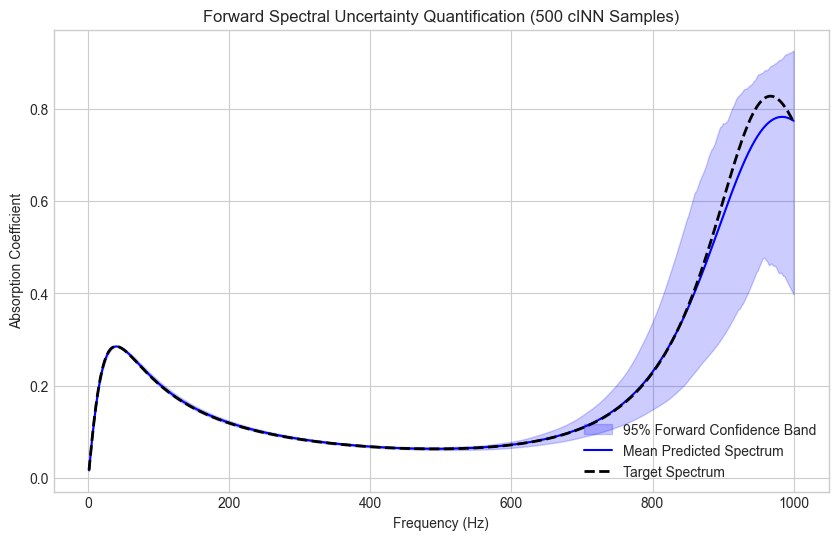

In [19]:
# ### 7. Uncertainty Quantification & Posterior Analysis
import scipy.stats as stats

def evaluate_cinn_uncertainty(test_idx, model, scaler, num_samples=500):
    model.eval()
    
    # 1. Prepare Target and Ground Truth
    target_spectrum = Y_test[test_idx]
    true_params_norm = X_test[test_idx]
    true_params_real = scaler.inverse_transform(true_params_norm.reshape(1, -1))[0]
    
    target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_samples, 1).to(device)
    z_random = torch.randn(num_samples, 20).to(device)
    
    # 2. Sample the Posterior (Generate 500 candidates)
    with torch.no_grad():
        generated_norm = model(z_random, target_tensor, rev=True)
        
        # Exact Likelihood of the Ground Truth (Metric 4)
        true_x_tensor = torch.FloatTensor(true_params_norm).unsqueeze(0).to(device)
        target_single = torch.FloatTensor(target_spectrum).unsqueeze(0).to(device)
        z_true, log_det_J = model(true_x_tensor, target_single, rev=False)
        true_nll = torch.mean(0.5 * torch.sum(z_true**2, dim=1) - log_det_J).item()
        
    generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
    generated_params = validate_and_clip_parameters(generated_params)
    
    # 3. Parameter Uncertainty (Metric 1 & 2)
    param_means = np.mean(generated_params, axis=0)
    param_stds = np.std(generated_params, axis=0)
    cov = (param_stds / (param_means + 1e-8)) * 100 # Coefficient of Variation (%)
    
    # 95% Confidence Intervals for Parameters
    lower_bound_95 = np.percentile(generated_params, 2.5, axis=0)
    upper_bound_95 = np.percentile(generated_params, 97.5, axis=0)
    
    # Calculate PICP (How many true parameters fall inside the 95% CI?)
    in_bounds = (true_params_real >= lower_bound_95) & (true_params_real <= upper_bound_95)
    picp = np.mean(in_bounds) * 100
    
    # 4. Spectral Uncertainty (Metric 3)
    print(f"Running TMM Physics Engine for {num_samples} posterior samples...")
    simulated_spectra = batch_physics_evaluation(generated_params)
    
    mean_spectrum = np.mean(simulated_spectra, axis=0)
    std_spectrum = np.std(simulated_spectra, axis=0)
    spectral_lower_95 = np.percentile(simulated_spectra, 2.5, axis=0)
    spectral_upper_95 = np.percentile(simulated_spectra, 97.5, axis=0)
    
    # --- PRINT REPORT ---
    print("\n" + "="*50)
    print(" cINN UNCERTAINTY QUANTIFICATION REPORT")
    print("="*50)
    print(f"1. Mean Coefficient of Variation (CoV):  {np.mean(cov):.2f}%")
    print(f"   (Higher % means the model found high physical degeneracy)")
    print(f"2. Parameter 95% PICP:                   {picp:.1f}%")
    print(f"   (Ideally close to 95.0%, meaning true physics are bounded)")
    print(f"3. Mean Spectral Forward Std Dev:        {np.mean(std_spectrum):.4f}")
    print(f"   (Low value means all 500 designs yield the exact same curve)")
    print(f"4. Ground Truth Exact NLL:               {true_nll:.4f}")
    print(f"   (Highly negative means the model strongly predicted the truth)")
    print("="*50)
    
    # --- PLOTTING SPECTRAL UNCERTAINTY ---
    frequencies = np.arange(1, 1001)
    plt.figure(figsize=(10, 6))
    
    # Plot 95% Confidence Band
    plt.fill_between(frequencies, spectral_lower_95, spectral_upper_95, color='blue', alpha=0.2, label='95% Forward Confidence Band')
    
    # Plot Mean Prediction and Target
    plt.plot(frequencies, mean_spectrum, color='blue', label='Mean Predicted Spectrum')
    plt.plot(frequencies, target_spectrum, color='black', linestyle='--', linewidth=2, label='Target Spectrum')
    
    plt.title('Forward Spectral Uncertainty Quantification (500 cINN Samples)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Absorption Coefficient')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Run the evaluation on the first test sample
evaluate_cinn_uncertainty(test_idx=0, model=model, scaler=scaler_params, num_samples=500)


🧪 STARTING COMPREHENSIVE cINN VALIDATION SUITE

TEST 1: FORWARD-INVERSE CYCLE CONSISTENCY

📊 Results from 50 tests:
   Spectrum MAE:   Mean=0.000927, Max=0.006485
   Parameter MAE:  Mean=643874.00, Max=2508584.23

✅ PASS if Spectrum MAE < 0.01
⚠️  Parameter MAE is high due to one-to-many degeneracy (expected)

TEST 2: INVERSE-FORWARD CONSISTENCY (SELF-CONSISTENCY)
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidate

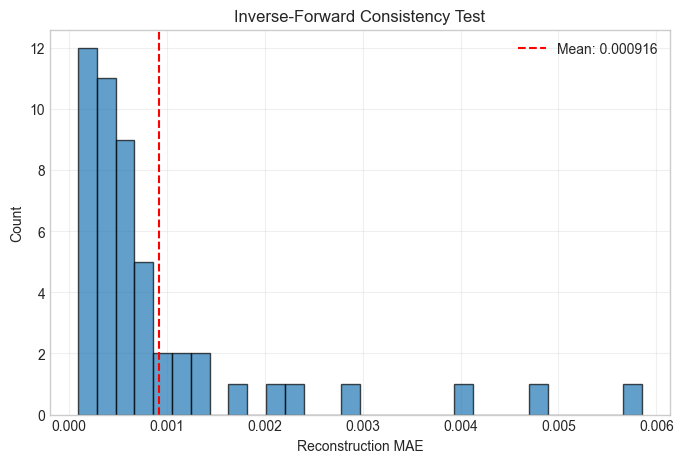


TEST 3: LATENT SPACE GAUSSIANITY (Normalizing Flow Validation)

📊 Testing 1000 samples across 20 latent dimensions:
   Mean p-value: 0.3161
   Dimensions passing (p > 0.05): 16/20 (80.0%)

✅ PASS if > 15/20 dimensions are Gaussian (p > 0.05)


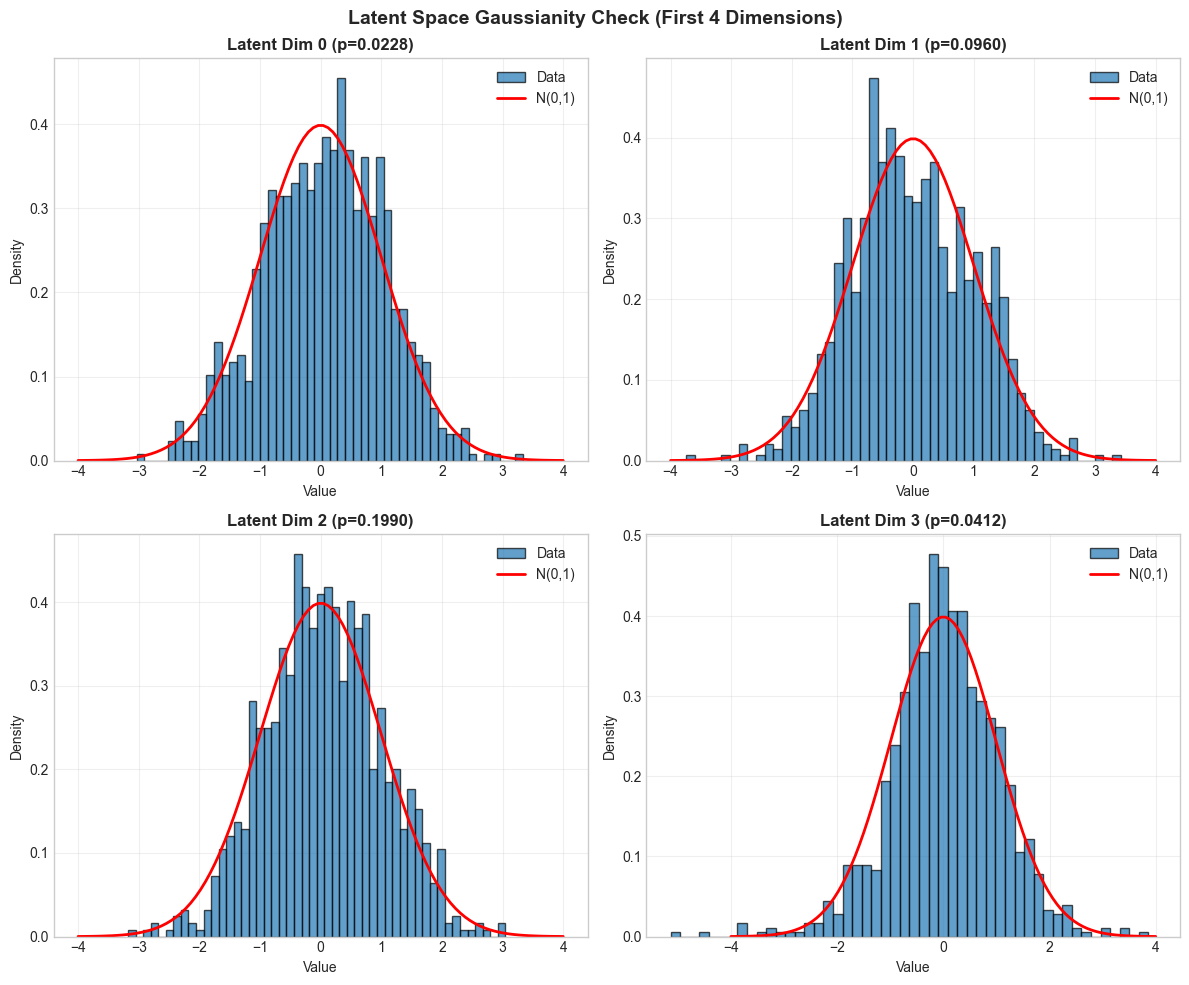


TEST 4: PARAMETER DIVERSITY (One-to-Many Capability)

📊 Diversity Metrics (100 candidates):
   Mean pairwise Euclidean distance: 6534674.22
   Std dev:                          5101749.78
   Min distance:                     2375.28
   Max distance:                     32787206.56

📊 Per-parameter Standard Deviations:
   d1   :     5.03
   d2   :     5.11
   d3   :     5.21
   d4   :     4.74
   d5   :     5.09
   d6   :     5.48
   d7   :     5.05
   d8   :     5.19
   d9   :     4.97
   d10  :     5.06
   m2   :   522.28
   m3   :   505.83
   m5   :   570.88
   m6   :   535.88
   m8   :   537.70
   m9   :   564.61
   rho  :   147.35
   eta  :     0.00
   E    : 5832774.48
   nu   :     0.02

✅ PASS if mean distance > 10 (parameters are diverse)


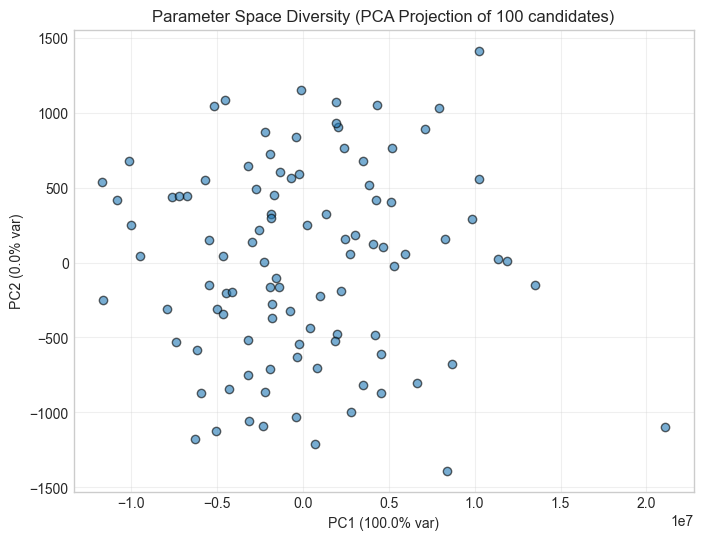


TEST 5: OUT-OF-DISTRIBUTION ROBUSTNESS

🔍 Testing: Flat 50% absorption
Evaluating 10 cINN generated candidates through physics engine...
   ✅ RMSE=0.1372, MAE=0.1205, R²=-inf

🔍 Testing: Linear ramp 0→1
Evaluating 10 cINN generated candidates through physics engine...
   ✅ RMSE=0.1992, MAE=0.1757, R²=0.5248

🔍 Testing: Step function
Evaluating 10 cINN generated candidates through physics engine...
   ✅ RMSE=0.4802, MAE=0.3784, R²=0.0775

🔍 Testing: High freq oscillation
Evaluating 10 cINN generated candidates through physics engine...
   ✅ RMSE=0.2520, MAE=0.2136, R²=-0.4054

✅ Model should gracefully handle OOD spectra (may not fit perfectly)

TEST 6: JACOBIAN DETERMINANT STABILITY

📊 Jacobian Statistics:
   Mean log|det(J)|: 16.7284
   Std dev:          1.8836
   Min:              10.9869
   Max:              20.6360
   NaN values:       0
   Inf values:       0

✅ PASS if NaN=0 and Inf=0


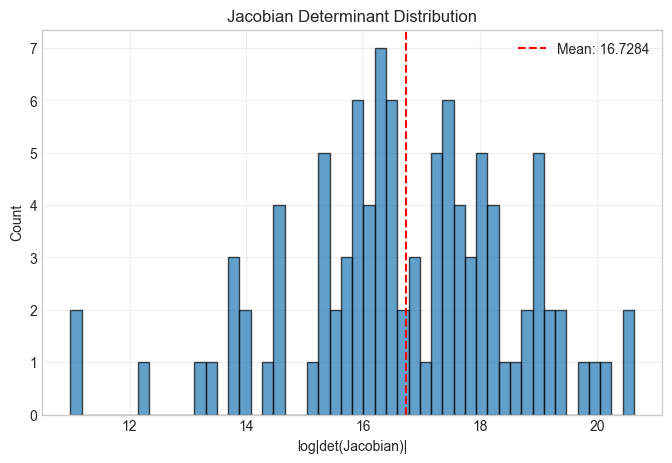


✅ VALIDATION SUITE COMPLETE


In [20]:
def test_forward_inverse_consistency(model, scaler, num_tests=50):
    """
    Test if: Real Params → TMM → Spectrum → cINN → Predicted Params
    results in similar parameters (accounting for degeneracy).
    """
    print("\n" + "="*70)
    print("TEST 1: FORWARD-INVERSE CYCLE CONSISTENCY")
    print("="*70)
    
    model.eval()
    param_errors = []
    spectrum_errors = []
    
    for idx in range(num_tests):
        # Get real parameters and their spectrum
        real_params_norm = X_test[idx]
        real_params = scaler.inverse_transform(real_params_norm.reshape(1, -1))[0]
        target_spectrum = Y_test[idx]
        
        # Generate candidates via cINN
        target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(10, 1).to(device)
        z_random = torch.randn(10, 20).to(device)
        
        with torch.no_grad():
            generated_norm = model(z_random, target_tensor, rev=True)
        
        generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
        generated_params = validate_and_clip_parameters(generated_params)
        
        # Run all candidates through physics
        simulated_spectra = batch_physics_evaluation(generated_params)
        
        # Find best match
        rmses = np.sqrt(np.mean((simulated_spectra - target_spectrum) ** 2, axis=1))
        best_idx = np.argmin(rmses)
        best_params = generated_params[best_idx]
        best_spectrum = simulated_spectra[best_idx]
        
        # Calculate errors
        param_mae = np.mean(np.abs(best_params - real_params))
        spectrum_mae = np.mean(np.abs(best_spectrum - target_spectrum))
        
        param_errors.append(param_mae)
        spectrum_errors.append(spectrum_mae)
    
    print(f"\n📊 Results from {num_tests} tests:")
    print(f"   Spectrum MAE:   Mean={np.mean(spectrum_errors):.6f}, Max={np.max(spectrum_errors):.6f}")
    print(f"   Parameter MAE:  Mean={np.mean(param_errors):.2f}, Max={np.max(param_errors):.2f}")
    print(f"\n✅ PASS if Spectrum MAE < 0.01")
    print(f"⚠️  Parameter MAE is high due to one-to-many degeneracy (expected)")
    
    return param_errors, spectrum_errors


def test_inverse_forward_consistency(model, scaler, num_tests=50):
    """
    Test if: Target Spectrum → cINN → Params → TMM → Reconstructed Spectrum
    returns the same spectrum.
    """
    print("\n" + "="*70)
    print("TEST 2: INVERSE-FORWARD CONSISTENCY (SELF-CONSISTENCY)")
    print("="*70)
    
    model.eval()
    reconstruction_errors = []
    
    for idx in range(num_tests):
        target_spectrum = Y_test[idx]
        
        # cINN inverse design
        best_params, best_spectrum, _ = inverse_design_cinn(
            target_spectrum, model, scaler, num_candidates=10
        )
        
        # Calculate reconstruction error
        mae = np.mean(np.abs(best_spectrum - target_spectrum))
        reconstruction_errors.append(mae)
    
    print(f"\n📊 Reconstruction Error Statistics:")
    print(f"   Mean MAE: {np.mean(reconstruction_errors):.6f}")
    print(f"   Median:   {np.median(reconstruction_errors):.6f}")
    print(f"   Max:      {np.max(reconstruction_errors):.6f}")
    print(f"   Std:      {np.std(reconstruction_errors):.6f}")
    
    print(f"\n✅ PASS if Mean MAE < 0.01")
    
    # Plot distribution
    plt.figure(figsize=(8, 5))
    plt.hist(reconstruction_errors, bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(np.mean(reconstruction_errors), color='r', linestyle='--', 
                label=f'Mean: {np.mean(reconstruction_errors):.6f}')
    plt.xlabel('Reconstruction MAE')
    plt.ylabel('Count')
    plt.title('Inverse-Forward Consistency Test')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return reconstruction_errors

def test_latent_gaussianity(model, X_test, Y_test, num_samples=1000):
    """
    Test if the latent space follows N(0, I) distribution.
    """
    print("\n" + "="*70)
    print("TEST 3: LATENT SPACE GAUSSIANITY (Normalizing Flow Validation)")
    print("="*70)
    
    model.eval()
    
    # Sample random test data
    sample_indices = np.random.choice(len(X_test), num_samples, replace=False)
    
    all_z = []
    for idx in sample_indices:
        x = torch.FloatTensor(X_test[idx]).unsqueeze(0).to(device)
        c = torch.FloatTensor(Y_test[idx]).unsqueeze(0).to(device)
        
        with torch.no_grad():
            z, _ = model(x, c, rev=False)
        
        all_z.append(z.cpu().numpy()[0])
    
    all_z = np.array(all_z)  # Shape: (num_samples, 20)
    
    # Test each latent dimension
    print(f"\n📊 Testing {num_samples} samples across 20 latent dimensions:")
    
    ks_pvalues = []
    for dim in range(20):
        # Kolmogorov-Smirnov test against N(0, 1)
        statistic, pvalue = stats.kstest(all_z[:, dim], 'norm', args=(0, 1))
        ks_pvalues.append(pvalue)
    
    mean_pvalue = np.mean(ks_pvalues)
    num_pass = np.sum(np.array(ks_pvalues) > 0.05)  # p > 0.05 means accept null (Gaussian)
    
    print(f"   Mean p-value: {mean_pvalue:.4f}")
    print(f"   Dimensions passing (p > 0.05): {num_pass}/20 ({100*num_pass/20:.1f}%)")
    
    print(f"\n✅ PASS if > 15/20 dimensions are Gaussian (p > 0.05)")
    
    # Visualize first 4 dimensions
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for i, ax in enumerate(axes.flat):
        ax.hist(all_z[:, i], bins=50, density=True, alpha=0.7, edgecolor='black', label='Data')
        
        # Overlay theoretical N(0,1)
        x_range = np.linspace(-4, 4, 100)
        ax.plot(x_range, stats.norm.pdf(x_range, 0, 1), 'r-', linewidth=2, label='N(0,1)')
        
        ax.set_title(f'Latent Dim {i} (p={ks_pvalues[i]:.4f})', fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Latent Space Gaussianity Check (First 4 Dimensions)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return ks_pvalues, all_z

def test_parameter_diversity(model, scaler, test_idx=0, num_candidates=100):
    """
    Test if cINN generates diverse candidates for the same target.
    """
    print("\n" + "="*70)
    print("TEST 4: PARAMETER DIVERSITY (One-to-Many Capability)")
    print("="*70)
    
    model.eval()
    target_spectrum = Y_test[test_idx]
    
    # Generate many candidates
    target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_candidates, 1).to(device)
    z_random = torch.randn(num_candidates, 20).to(device)
    
    with torch.no_grad():
        generated_norm = model(z_random, target_tensor, rev=True)
    
    generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
    generated_params = validate_and_clip_parameters(generated_params)
    
    # Calculate pairwise distances
    from scipy.spatial.distance import pdist
    
    pairwise_dists = pdist(generated_params, metric='euclidean')
    mean_dist = np.mean(pairwise_dists)
    std_dist = np.std(pairwise_dists)
    
    print(f"\n📊 Diversity Metrics ({num_candidates} candidates):")
    print(f"   Mean pairwise Euclidean distance: {mean_dist:.2f}")
    print(f"   Std dev:                          {std_dist:.2f}")
    print(f"   Min distance:                     {np.min(pairwise_dists):.2f}")
    print(f"   Max distance:                     {np.max(pairwise_dists):.2f}")
    
    # Check per-parameter std dev
    param_stds = np.std(generated_params, axis=0)
    print(f"\n📊 Per-parameter Standard Deviations:")
    for i, (name, std_val) in enumerate(zip(PARAM_NAMES, param_stds)):
        print(f"   {name:5s}: {std_val:>8.2f}")
    
    print(f"\n✅ PASS if mean distance > 10 (parameters are diverse)")
    
    # Visualize diversity in 2D (PCA)
    from sklearn.decomposition import PCA
    
    pca = PCA(n_components=2)
    coords_2d = pca.fit_transform(generated_params)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(coords_2d[:, 0], coords_2d[:, 1], alpha=0.6, edgecolors='black')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
    plt.title(f'Parameter Space Diversity (PCA Projection of {num_candidates} candidates)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return generated_params, pairwise_dists

def test_ood_robustness(model, scaler):
    """
    Test cINN on synthetic spectra it has never seen.
    """
    print("\n" + "="*70)
    print("TEST 5: OUT-OF-DISTRIBUTION ROBUSTNESS")
    print("="*70)
    
    model.eval()
    
    # Create synthetic test cases
    synthetic_spectra = {
        "Flat 50% absorption": np.ones(1000) * 0.5,
        "Linear ramp 0→1": np.linspace(0, 1, 1000),
        "Step function": np.concatenate([np.zeros(500), np.ones(500)]),
        "High freq oscillation": 0.5 + 0.3 * np.sin(np.arange(1000) * 0.1),
    }
    
    results = {}
    
    for name, spectrum in synthetic_spectra.items():
        print(f"\n🔍 Testing: {name}")
        
        try:
            best_params, best_pred, rmse = inverse_design_cinn(
                spectrum, model, scaler, num_candidates=10
            )
            
            mae = np.mean(np.abs(best_pred - spectrum))
            r2 = 1 - (np.sum((spectrum - best_pred)**2) / np.sum((spectrum - np.mean(spectrum))**2))
            
            results[name] = {
                'rmse': rmse,
                'mae': mae,
                'r2': r2,
                'success': True
            }
            
            print(f"   ✅ RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
            
        except Exception as e:
            results[name] = {'success': False, 'error': str(e)}
            print(f"   ❌ FAILED: {e}")
    
    print(f"\n✅ Model should gracefully handle OOD spectra (may not fit perfectly)")
    
    return results

def test_jacobian_stability(model, X_test, Y_test, num_samples=100):
    """
    Test if log|det(J)| values are stable (not NaN/Inf).
    """
    print("\n" + "="*70)
    print("TEST 6: JACOBIAN DETERMINANT STABILITY")
    print("="*70)
    
    model.eval()
    
    log_det_values = []
    
    for idx in range(min(num_samples, len(X_test))):
        x = torch.FloatTensor(X_test[idx]).unsqueeze(0).to(device)
        c = torch.FloatTensor(Y_test[idx]).unsqueeze(0).to(device)
        
        with torch.no_grad():
            _, log_det_J = model(x, c, rev=False)
        
        log_det_values.append(log_det_J.item())
    
    log_det_values = np.array(log_det_values)
    
    num_nan = np.sum(np.isnan(log_det_values))
    num_inf = np.sum(np.isinf(log_det_values))
    
    print(f"\n📊 Jacobian Statistics:")
    print(f"   Mean log|det(J)|: {np.mean(log_det_values):.4f}")
    print(f"   Std dev:          {np.std(log_det_values):.4f}")
    print(f"   Min:              {np.min(log_det_values):.4f}")
    print(f"   Max:              {np.max(log_det_values):.4f}")
    print(f"   NaN values:       {num_nan}")
    print(f"   Inf values:       {num_inf}")
    
    print(f"\n✅ PASS if NaN=0 and Inf=0")
    
    # Plot distribution
    plt.figure(figsize=(8, 5))
    plt.hist(log_det_values, bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(np.mean(log_det_values), color='r', linestyle='--', 
                label=f'Mean: {np.mean(log_det_values):.4f}')
    plt.xlabel('log|det(Jacobian)|')
    plt.ylabel('Count')
    plt.title('Jacobian Determinant Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return log_det_values


def run_full_validation_suite():
    """
    Execute all validation tests in sequence.
    """
    print("\n" + "="*80)
    print("🧪 STARTING COMPREHENSIVE cINN VALIDATION SUITE")
    print("="*80)
    
    results = {}
    
    # Test 1
    try:
        results['forward_inverse'], _ = test_forward_inverse_consistency(model, scaler_params, 50)
    except Exception as e:
        print(f"❌ Test 1 failed: {e}")
    
    # Test 2
    try:
        results['inverse_forward'] = test_inverse_forward_consistency(model, scaler_params, 50)
    except Exception as e:
        print(f"❌ Test 2 failed: {e}")
    
    # Test 3
    try:
        results['latent_pvalues'], _ = test_latent_gaussianity(model, X_test, Y_test, 1000)
    except Exception as e:
        print(f"❌ Test 3 failed: {e}")
    
    # Test 4
    try:
        _, results['diversity_dists'] = test_parameter_diversity(model, scaler_params, 0, 100)
    except Exception as e:
        print(f"❌ Test 4 failed: {e}")
    
    # Test 5
    try:
        results['ood'] = test_ood_robustness(model, scaler_params)
    except Exception as e:
        print(f"❌ Test 5 failed: {e}")
    
    # Test 6
    try:
        results['jacobians'] = test_jacobian_stability(model, X_test, Y_test, 100)
    except Exception as e:
        print(f"❌ Test 6 failed: {e}")
    
    print("\n" + "="*80)
    print("✅ VALIDATION SUITE COMPLETE")
    print("="*80)
    
    return results

# Execute all tests
validation_results = run_full_validation_suite()

In [21]:
# ============================================================================
# 9. INTERACTIVE VISUALIZATION: TOP 5 CANDIDATES (PLOTLY)
# ============================================================================
import random
import numpy as np
import torch
import plotly.graph_objects as go

print("\n" + "="*80)
print("🎨 GENERATING INTERACTIVE TOP-5 CANDIDATE PLOTS")
print("="*80)

# Pick 5 random indices from the Test Set
num_samples_to_plot = 5
random_indices = random.sample(range(len(Y_test)), num_samples_to_plot)
num_candidates = 20
frequencies = np.arange(1, 1001)

model.eval()

# High-contrast publication colors and dash styles
colors = ['#D81B60', '#1E88E5', '#FFC107', '#004D40', '#8E24AA']
dash_styles = ['solid', 'dash', 'dashdot', 'dot', 'longdash']

for sample_idx in random_indices:
    target_spectrum = Y_test[sample_idx]
    
    # 1. Generate 20 candidates
    target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_candidates, 1).to(device)
    z_random = torch.randn(num_candidates, 20).to(device)
    
    with torch.no_grad():
        generated_norm = model(z_random, target_tensor, rev=True)
        
    generated_params_raw = scaler_params.inverse_transform(generated_norm.cpu().numpy())
    generated_params = validate_and_clip_parameters(generated_params_raw)
    
    # 2. Forward simulate all 20 candidates
    simulated_spectra = batch_physics_evaluation(generated_params)
    
    # 3. Rank the candidates by RMSE
    rmses = np.sqrt(np.mean((simulated_spectra - target_spectrum) ** 2, axis=1))
    top_5_indices = np.argsort(rmses)[:5]
    
    # 4. Initialize the Interactive Plotly Figure
    fig = go.Figure()

    # Add the candidates first
    for rank, c_idx in enumerate(top_5_indices):
        cand_spectrum = simulated_spectra[c_idx]
        
        # Calculate Mean Relative Error
        epsilon = 1e-8
        rel_errors = np.abs(cand_spectrum - target_spectrum) / (np.abs(target_spectrum) + epsilon)
        mean_rel_error = np.mean(rel_errors) * 100
        
        fig.add_trace(go.Scatter(
            x=frequencies, 
            y=cand_spectrum,
            mode='lines',
            name=f'Rank {rank+1} (Rel. Err: {mean_rel_error:.2f}%)',
            line=dict(color=colors[rank], width=4, dash=dash_styles[rank]),
            opacity=0.85
        ))

   # Add the Target Spectrum last so it stays on top
    fig.add_trace(go.Scatter(
        x=frequencies, 
        y=target_spectrum,
        mode='lines',
        name='<b>Target Spectrum</b>',
        line=dict(color='black', width=3), # <--- THICKNESS IS HERE
        opacity=1.0
    ))

    # 5. Format the Interactive Layout
    fig.update_layout(
        title=f'<b>Test Sample Index: {sample_idx} | Interactive Generative Diversity</b>',
        xaxis_title='<b>Frequency (Hz)</b>',
        yaxis_title='<b>Absorption Coefficient</b>',
        template='plotly_white',
        hovermode='x unified', # Shows a vertical line with all values at the hovered frequency
        legend=dict(
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.02, # Puts the legend completely outside the plot
            bgcolor="rgba(255,255,255,0.9)",
            bordercolor="black",
            borderwidth=1
        ),
        margin=dict(l=60, r=250, t=60, b=60), # Extra right margin for the legend
        height=500
    )
    
    # Ensure axes limits are strict
    fig.update_xaxes(range=[1, 1000])
    fig.update_yaxes(range=[-0.05, 1.05])

    # Render the plot inside the notebook
    fig.show()


🎨 GENERATING INTERACTIVE TOP-5 CANDIDATE PLOTS
